# Classification Robuste et Analyse de Decision en Environnement Critique
## Detection de Fraudes Bancaires — Credit Card Fraud Detection (Kaggle)

**Auteur :** Mustapha EL MIFDALI, Hicham Ouaouche, ILYAS MOUSSNAOUI, ABOUBAKER ID HAMIDE    |  **Module :** Intelligence Artificielle  |  **2025-2026**

---
Dataset : **284 807 transactions** | Ratio de desequilibre : **578:1**

Ce notebook contient les **4 etapes** du projet, entierement executees avec toutes les figures :
1. **EDA & Preparation** — Analyse exploratoire, feature engineering, gestion du desequilibre
2. **Modeles** — Logistic Regression (Elastic Net), Random Forest, XGBoost + Optuna (50 trials)
3. **Evaluation & Calibration** — F1-Macro, AUPRC, MCC, Platt Scaling, Isotonic Regression
4. **Interpretabilite SHAP** — Explications globales et individuelles



---
# Etape 1 : Analyse Exploratoire et Preparation des Donnees

*EDA, feature engineering (7 variables), analyse VIF, 4 methodes de desequilibre*


In [1]:
import sys


import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.utils.class_weight import compute_class_weight
from sklearn.decomposition import PCA
from statsmodels.stats.outliers_influence import variance_inflation_factor
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import NearMiss
from matplotlib.patches import Patch
import pickle

# ─── Chemins ─────────────────────────────────────────────────────────────────
ROOT       = ROOT
DATA_PATH  = ROOT / "data" / "creditcard.csv"
FIG_DIR    = ROOT / "etape1_eda" / "figures"   # ← figures dans le dossier de l'étape
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_PICKLE = ROOT / "etape1_eda" / "prepared_data.pkl"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})
C = {
    "maj":    "#4C72B0",
    "min":    "#DD8452",
    "green":  "#2ecc71",
    "purple": "#9b59b6",
    "red":    "#e74c3c",
    "orange": "#f39c12",
    "teal":   "#1abc9c",
    "dark":   "#2c3e50",
}

def save_fig(fig, name):
    path = FIG_DIR / name
    fig.savefig(path, bbox_inches="tight", dpi=130)
    print(f"  ✓ {name}  →  {path}")

# ─────────────────────────────────────────────────────────────────────────────
print("=" * 65)
print("ÉTAPE 1 – EDA et Préparation")
print("=" * 65)

df = pd.read_csv(DATA_PATH)
print(f"Shape : {df.shape}")
print(f"Valeurs nulles : {df.isnull().sum().sum()}")
vc = df["Class"].value_counts()
print(f"\nDistribution des classes :\n{vc}")
print(f"Ratio déséquilibre : {vc[0]/vc[1]:.0f}:1")

df_legit = df[df["Class"] == 0]
df_fraud = df[df["Class"] == 1]

NameError: name 'ROOT' is not defined

### FIG 01 – Distribution des classes

  ✓ fig01_class_distribution.png  →  C:\Users\DELL\Desktop\IA_P1\etape1_eda\figures\fig01_class_distribution.png


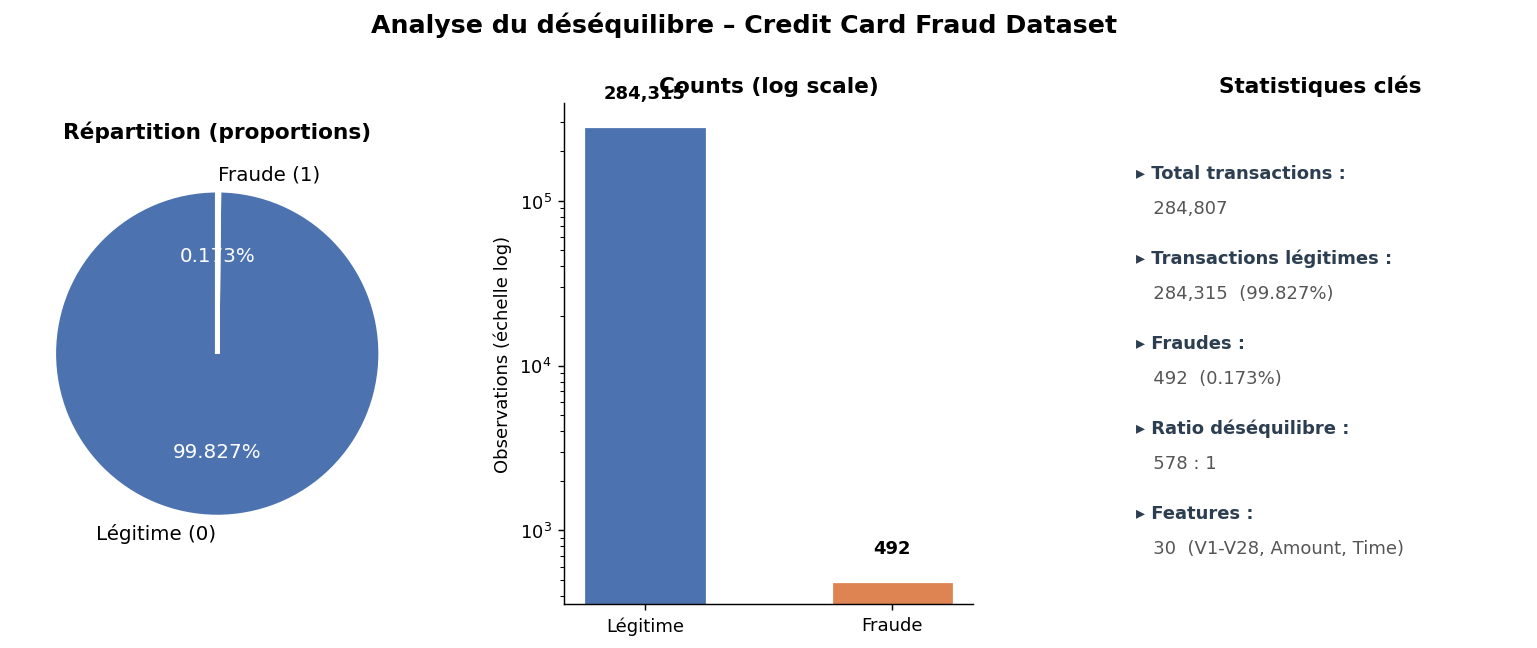

In [ ]:
fig = plt.figure(figsize=(15, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# Pie
ax0 = fig.add_subplot(gs[0])
wedges, texts, autotexts = ax0.pie(
    vc.values, labels=["Légitime (0)", "Fraude (1)"],
    colors=[C["maj"], C["min"]],
    autopct="%1.3f%%", startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2.5},
    textprops={"fontsize": 11},
)
autotexts[0].set_color("white"); autotexts[1].set_color("white")
ax0.set_title("Répartition (proportions)", fontsize=12, fontweight="bold")

# Bar (log)
ax1 = fig.add_subplot(gs[1])
bars = ax1.bar(["Légitime", "Fraude"], vc.values,
               color=[C["maj"], C["min"]], width=0.5,
               edgecolor="white", linewidth=1.8)
ax1.set_yscale("log")
ax1.set_ylabel("Observations (échelle log)")
ax1.set_title("Counts (log scale)", fontsize=12, fontweight="bold")
for bar, v in zip(bars, vc.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.4,
             f"{v:,}", ha="center", va="bottom", fontweight="bold")

# Donut + ratio
ax2 = fig.add_subplot(gs[2])
ax2.axis("off")
ratio = vc[0] / vc[1]
info = [
    ("Total transactions",    f"{len(df):,}"),
    ("Transactions légitimes",f"{vc[0]:,}  ({vc[0]/len(df)*100:.3f}%)"),
    ("Fraudes",               f"{vc[1]:,}  ({vc[1]/len(df)*100:.3f}%)"),
    ("Ratio déséquilibre",    f"{ratio:.0f} : 1"),
    ("Features",              f"{df.shape[1]-1}  (V1-V28, Amount, Time)"),
]
y_pos = 0.85
for label, val in info:
    ax2.text(0.05, y_pos, f"▸ {label} :", fontsize=10,
             fontweight="bold", transform=ax2.transAxes, color=C["dark"])
    ax2.text(0.05, y_pos - 0.07, f"   {val}", fontsize=10,
             transform=ax2.transAxes, color="#555")
    y_pos -= 0.17

ax2.set_title("Statistiques clés", fontsize=12, fontweight="bold")

plt.suptitle("Analyse du déséquilibre – Credit Card Fraud Dataset",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig(fig, "fig01_class_distribution.png")
plt.show()

### FIG 02 – Amount & Time

  ✓ fig02_amount_time_analysis.png  →  C:\Users\DELL\Desktop\IA_P1\etape1_eda\figures\fig02_amount_time_analysis.png


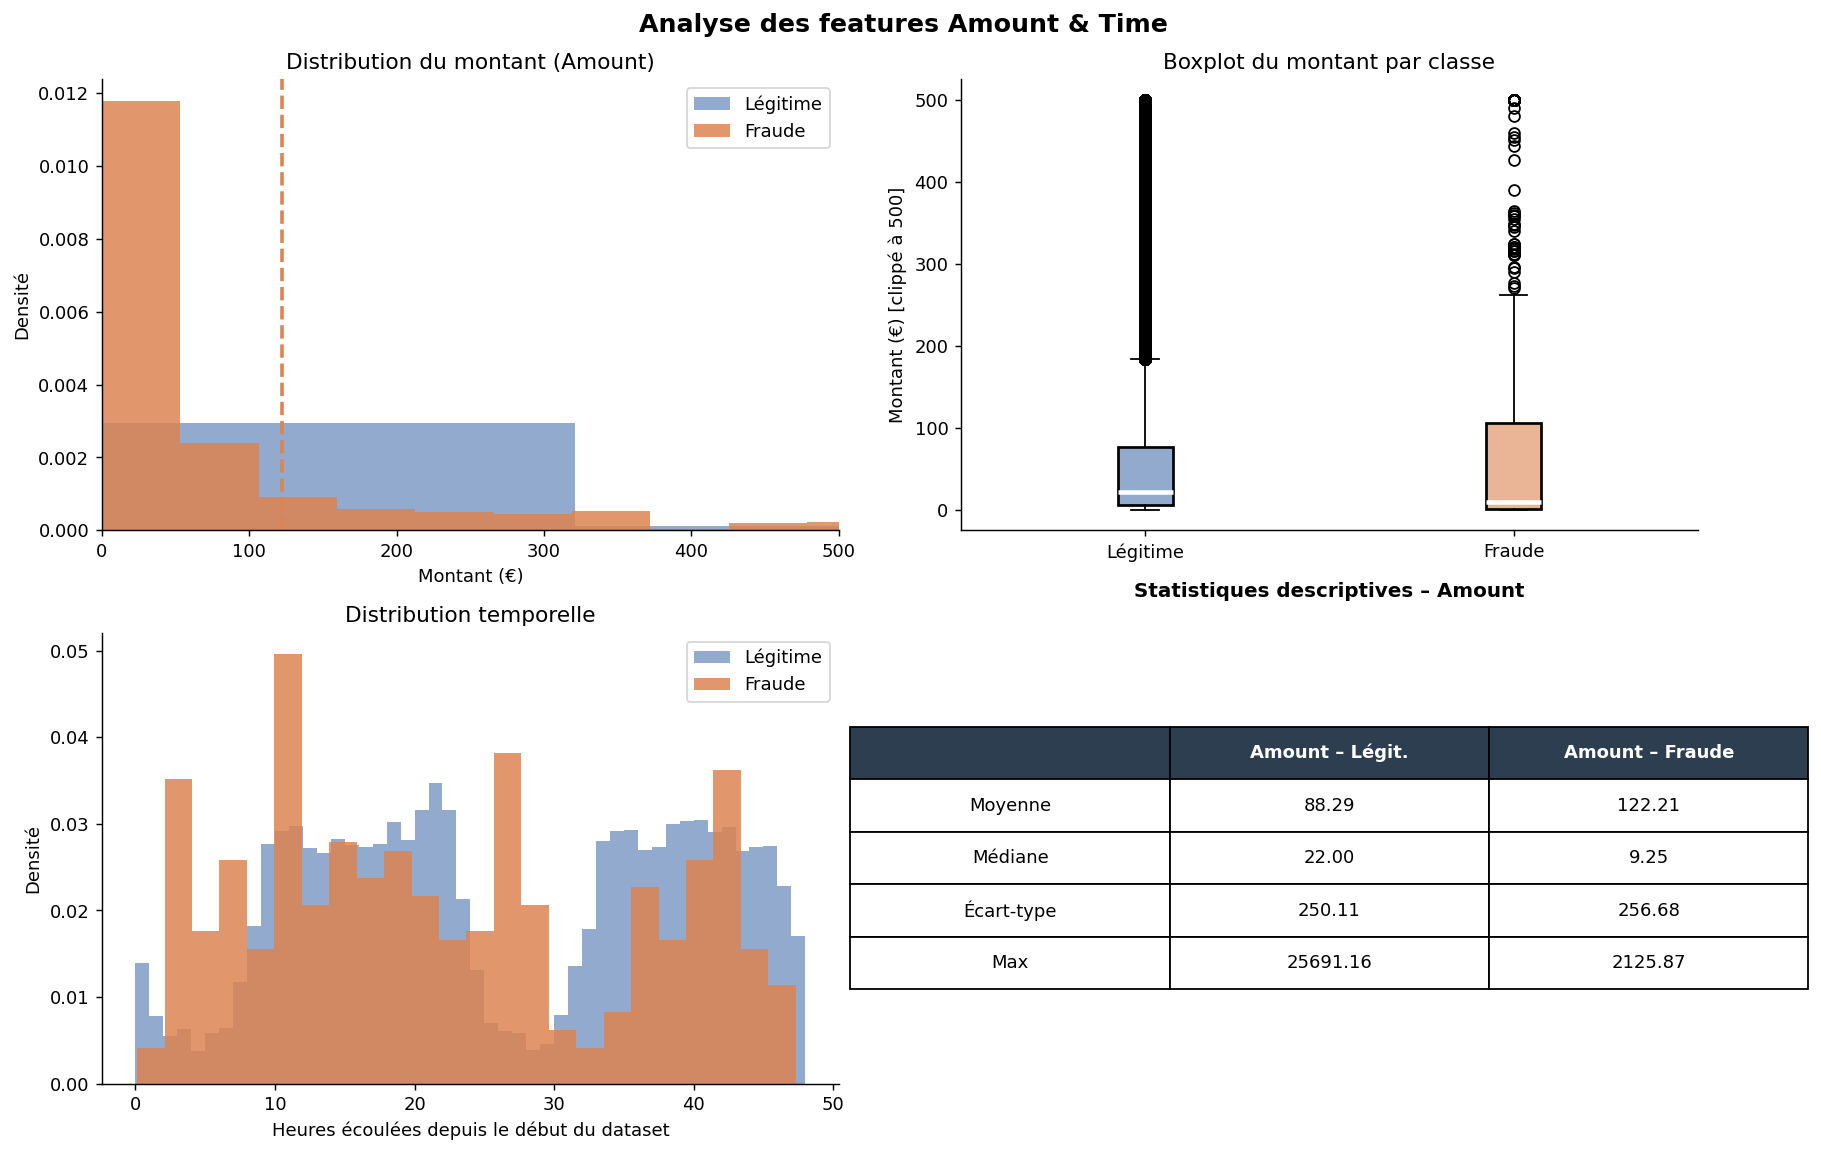

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Amount hist
ax = axes[0, 0]
ax.hist(df_legit["Amount"], bins=80, color=C["maj"], alpha=0.6,
        label="Légitime", density=True)
ax.hist(df_fraud["Amount"], bins=40, color=C["min"], alpha=0.85,
        label="Fraude", density=True)
ax.set_xlabel("Montant (€)"); ax.set_ylabel("Densité")
ax.set_xlim(0, 500); ax.legend()
ax.set_title("Distribution du montant (Amount)")
ax.axvline(df_fraud["Amount"].mean(), color=C["min"], lw=2, linestyle="--",
           label=f"Moy. fraude = {df_fraud['Amount'].mean():.1f}€")

# Amount boxplot
ax = axes[0, 1]
bp = ax.boxplot(
    [df_legit["Amount"].clip(0, 500).values, df_fraud["Amount"].clip(0, 500).values],
    labels=["Légitime", "Fraude"], patch_artist=True,
    boxprops=dict(linewidth=1.5),
    medianprops=dict(color="white", linewidth=2.5),
)
bp["boxes"][0].set_facecolor(C["maj"] + "99")
bp["boxes"][1].set_facecolor(C["min"] + "99")
ax.set_ylabel("Montant (€) [clippé à 500]")
ax.set_title("Boxplot du montant par classe")

# Time hist
ax = axes[1, 0]
ax.hist(df_legit["Time"] / 3600, bins=48, color=C["maj"], alpha=0.6,
        label="Légitime", density=True)
ax.hist(df_fraud["Time"] / 3600, bins=24, color=C["min"], alpha=0.85,
        label="Fraude", density=True)
ax.set_xlabel("Temps (heures)"); ax.set_ylabel("Densité")
ax.legend(); ax.set_title("Distribution temporelle")
ax.set_xlabel("Heures écoulées depuis le début du dataset")

# Stats table
ax = axes[1, 1]
ax.axis("off")
stats = pd.DataFrame({
    "": ["Moyenne", "Médiane", "Écart-type", "Max"],
    "Amount – Légit.": [
        f"{df_legit['Amount'].mean():.2f}",
        f"{df_legit['Amount'].median():.2f}",
        f"{df_legit['Amount'].std():.2f}",
        f"{df_legit['Amount'].max():.2f}",
    ],
    "Amount – Fraude": [
        f"{df_fraud['Amount'].mean():.2f}",
        f"{df_fraud['Amount'].median():.2f}",
        f"{df_fraud['Amount'].std():.2f}",
        f"{df_fraud['Amount'].max():.2f}",
    ],
})
table = ax.table(cellText=stats.values, colLabels=stats.columns,
                 loc="center", cellLoc="center")
table.auto_set_font_size(False); table.set_fontsize(10)
table.scale(1.3, 2.2)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor(C["dark"])
        cell.set_text_props(color="white", fontweight="bold")
ax.set_title("Statistiques descriptives – Amount", pad=20, fontsize=11, fontweight="bold")

plt.suptitle("Analyse des features Amount & Time", fontsize=14, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig02_amount_time_analysis.png")
plt.show()

### Feature engineering + Split stratifié + normalisation + sélection

In [ ]:
X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

def add_engineered_features(X_df):
    X_fe = X_df.copy()
    # Dataset déjà numérique : encodage non nécessaire, on enrichit via transformations.
    hours = (X_fe["Time"] / 3600.0) % 24.0
    X_fe["Amount_log1p"] = np.log1p(np.clip(X_fe["Amount"], a_min=0, a_max=None))
    X_fe["Amount_sq"] = X_fe["Amount"] ** 2
    X_fe["Time_sin"] = np.sin(2 * np.pi * hours / 24.0)
    X_fe["Time_cos"] = np.cos(2 * np.pi * hours / 24.0)
    X_fe["V1_V2_inter"] = X_fe["V1"] * X_fe["V2"]
    X_fe["V14_V17_inter"] = X_fe["V14"] * X_fe["V17"]
    return X_fe

X_train = add_engineered_features(X_train)
X_test  = add_engineered_features(X_test)

scale_cols = ["Amount", "Time", "Amount_log1p", "Amount_sq"]
scaler = StandardScaler()
X_train.loc[:, scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test.loc[:, scale_cols] = scaler.transform(X_test[scale_cols])

mi_sample_n = min(60000, len(X_train))
mi_idx = np.random.choice(len(X_train), mi_sample_n, replace=False)
mi_vals = mutual_info_classif(
    X_train.iloc[mi_idx], y_train.iloc[mi_idx], random_state=RANDOM_STATE
)
mi_series = pd.Series(mi_vals, index=X_train.columns).sort_values(ascending=False)

required_feats = ["V14", "V17", "V12", "V10", "V16", "Amount", "Time"]
selected_features = mi_series.head(min(30, len(mi_series))).index.tolist()
for feat in required_feats:
    if feat in X_train.columns and feat not in selected_features:
        selected_features.append(feat)

X_train = X_train[selected_features].copy()
X_test = X_test[selected_features].copy()

print("\nFeature engineering avancé : 7 variables créées (encodage non applicable au dataset).")
print(f"Mutual Information calculée sur un échantillon de {mi_sample_n:,} observations.")
print(f"Sélection statistique (Mutual Information) : {len(selected_features)} features conservées.")
print("Top 8 MI :")
print(mi_series.head(8).round(5).to_string())

print(f"\nTrain : {X_train.shape} | Test : {X_test.shape}")
print(f"Fraudes train : {y_train.sum()} ({y_train.mean():.4%})")


Feature engineering avancé : 7 variables créées (encodage non applicable au dataset).
Mutual Information calculée sur un échantillon de 60,000 observations.
Sélection statistique (Mutual Information) : 30 features conservées.
Top 8 MI :
V14_V17_inter    0.00676
V17              0.00641
V14              0.00620
V12              0.00598
V10              0.00593
V11              0.00512
V16              0.00424
V4               0.00384

Train : (227845, 30) | Test : (56962, 30)
Fraudes train : 394 (0.1729%)


### FIG 03 – Matrice de corrélation

  ✓ fig03_correlation_matrix.png  →  C:\Users\DELL\Desktop\IA_P1\etape1_eda\figures\fig03_correlation_matrix.png


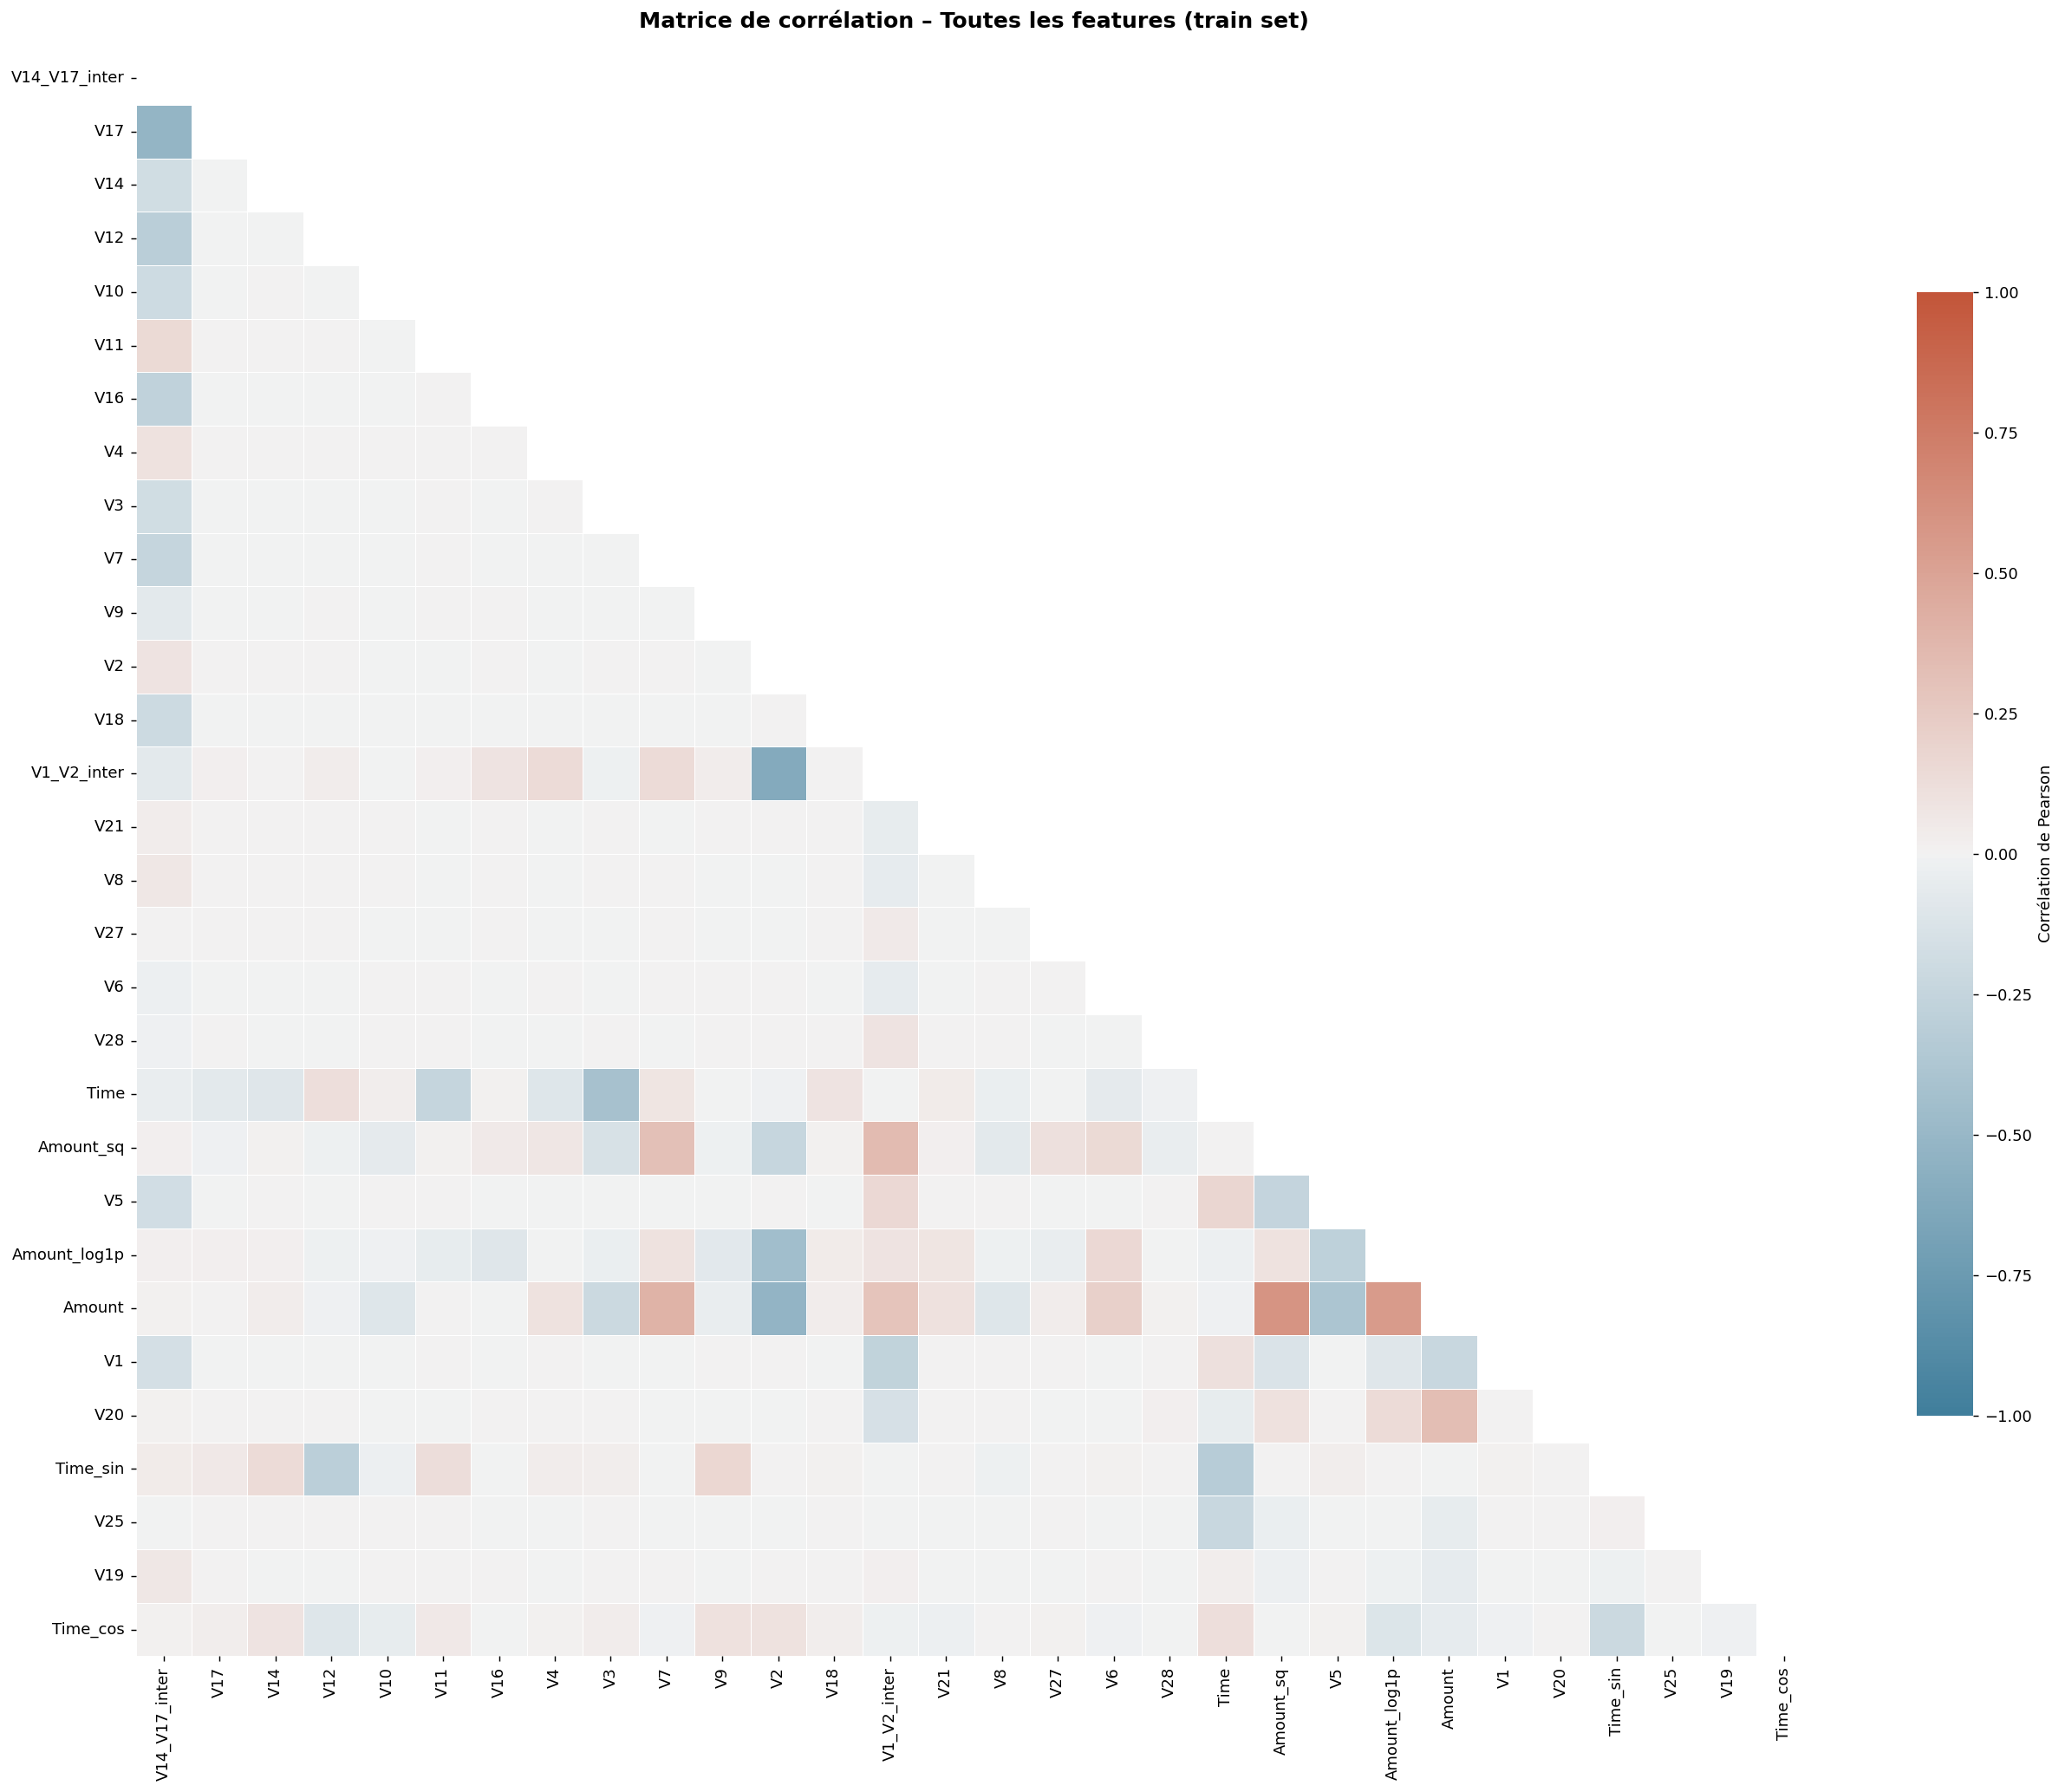

In [ ]:
fig, ax = plt.subplots(figsize=(20, 16))
corr = X_train.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, center=0, vmin=-1, vmax=1,
            linewidths=0.3, ax=ax,
            cbar_kws={"shrink": 0.7, "label": "Corrélation de Pearson"})
ax.set_title("Matrice de corrélation – Toutes les features (train set)",
             fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
save_fig(fig, "fig03_correlation_matrix.png")
plt.show()

### FIG 04 – Corrélations avec la target

  ✓ fig04_correlation_with_target.png  →  C:\Users\DELL\Desktop\IA_P1\etape1_eda\figures\fig04_correlation_with_target.png


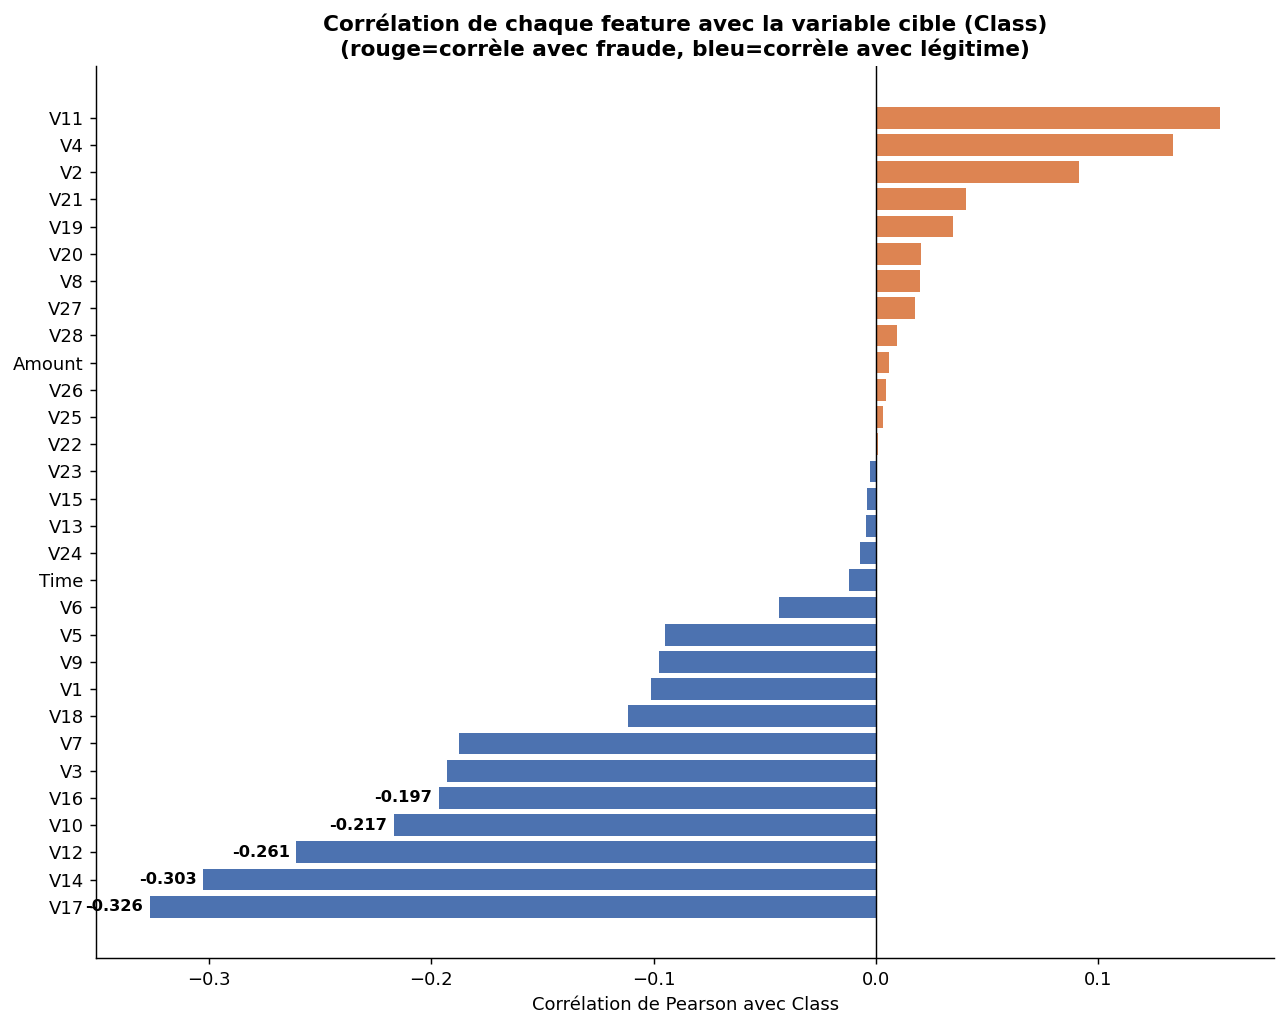

In [ ]:
corr_target = df.corr()["Class"].drop("Class").sort_values()
fig, ax = plt.subplots(figsize=(10, 8))
colors_c = [C["min"] if v > 0 else C["maj"] for v in corr_target]
ax.barh(corr_target.index, corr_target.values, color=colors_c)
ax.axvline(0, color="black", linewidth=0.8)

top5 = corr_target.abs().nlargest(5).index
for feat in top5:
    val = corr_target[feat]
    ax.text(val + (0.003 if val >= 0 else -0.003),
            list(corr_target.index).index(feat),
            f"{val:.3f}", va="center",
            ha="left" if val >= 0 else "right", fontsize=9, fontweight="bold")

ax.set_xlabel("Corrélation de Pearson avec Class")
ax.set_title("Corrélation de chaque feature avec la variable cible (Class)\n"
             "(rouge=corrèle avec fraude, bleu=corrèle avec légitime)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig04_correlation_with_target.png")
plt.show()

### VIF

In [ ]:
print("\n─── Calcul du VIF ───")
sample_vif = X_train.sample(5000, random_state=RANDOM_STATE).reset_index(drop=True)
vif_data = pd.DataFrame({
    "Feature": sample_vif.columns,
    "VIF": [variance_inflation_factor(sample_vif.values, i)
            for i in range(sample_vif.shape[1])]
}).sort_values("VIF", ascending=False).reset_index(drop=True)
print(vif_data.head(10).to_string(index=False))


─── Calcul du VIF ───
     Feature       VIF
      Amount 16.798265
          V2  7.624233
   Amount_sq  5.658412
 V1_V2_inter  4.549006
          V7  3.593047
          V5  2.548928
Amount_log1p  2.403771
         V20  2.004744
          V1  1.996997
          V3  1.965679


### FIG 05 – VIF

  ✓ fig05_vif.png  →  C:\Users\DELL\Desktop\IA_P1\etape1_eda\figures\fig05_vif.png


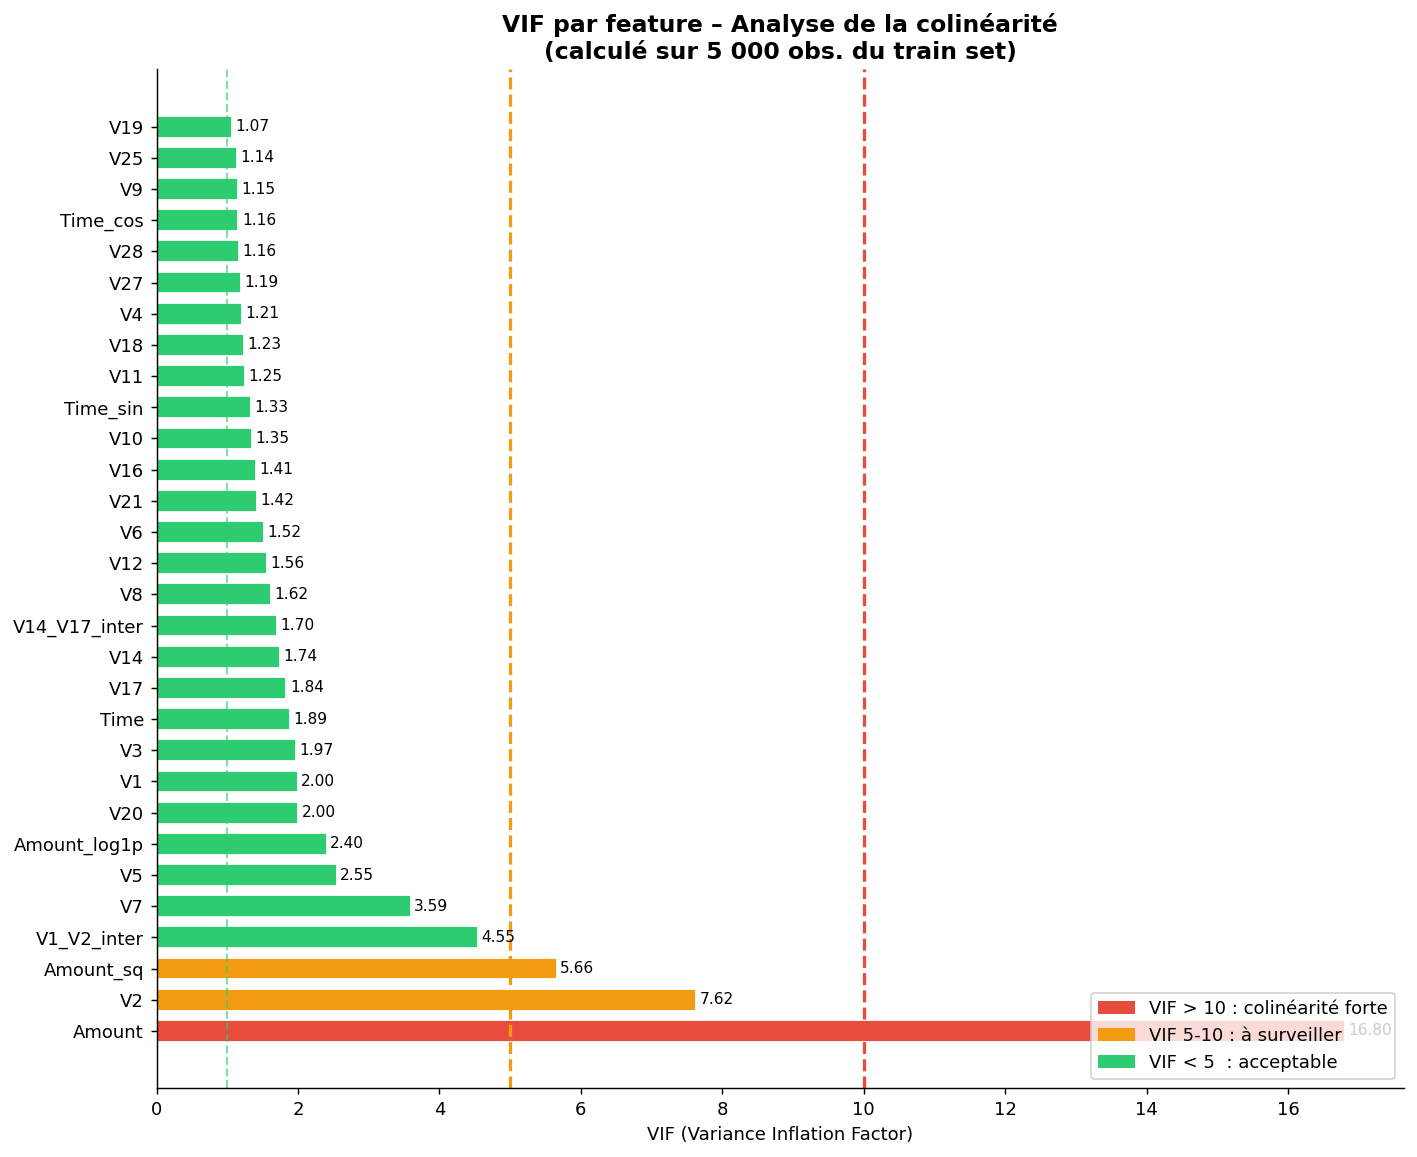

In [ ]:
def color_vif(v):
    if v > 10: return C["red"]
    if v > 5:  return C["orange"]
    return C["green"]

fig, ax = plt.subplots(figsize=(11, 9))
colors_vif = [color_vif(v) for v in vif_data["VIF"]]
bars = ax.barh(vif_data["Feature"], vif_data["VIF"],
               color=colors_vif, edgecolor="white", height=0.7)
ax.axvline(10, color=C["red"],    linestyle="--", linewidth=1.8)
ax.axvline(5,  color=C["orange"], linestyle="--", linewidth=1.8)
ax.axvline(1,  color=C["green"],  linestyle="--", linewidth=1.2, alpha=0.6)

for bar, val in zip(bars, vif_data["VIF"]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}", va="center", fontsize=8.5)

legend_els = [
    Patch(facecolor=C["red"],    label="VIF > 10 : colinéarité forte"),
    Patch(facecolor=C["orange"], label="VIF 5-10 : à surveiller"),
    Patch(facecolor=C["green"],  label="VIF < 5  : acceptable"),
]
ax.legend(handles=legend_els, loc="lower right", fontsize=10)
ax.set_xlabel("VIF (Variance Inflation Factor)")
ax.set_title("VIF par feature – Analyse de la colinéarité\n(calculé sur 5 000 obs. du train set)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig05_vif.png")
plt.show()

### GESTION DU DÉSÉQUILIBRE – 4 méthodes

In [ ]:
print("\n─── Calcul des 4 méthodes de gestion du déséquilibre ───")

# Méthode 1 : class_weight='balanced' (niveau algorithmique)
cw_arr  = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
cw_dict = dict(enumerate(cw_arr))
print(f"[1] Class weights : {cw_dict}")

# Méthode 2 : SMOTE (sur-échantillonnage synthétique)
print("[2] SMOTE …")
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_tr_smote, y_tr_smote = smote.fit_resample(X_train, y_train)
print(f"    Shape : {X_tr_smote.shape} | fraudes : {y_tr_smote.sum()}")

# Méthode 3 : ADASYN (sur-échantillonnage adaptatif)
print("[3] ADASYN …")
adasyn = ADASYN(random_state=RANDOM_STATE, n_neighbors=5)
X_tr_adasyn, y_tr_adasyn = adasyn.fit_resample(X_train, y_train)
print(f"    Shape : {X_tr_adasyn.shape} | fraudes : {y_tr_adasyn.sum()}")

# Méthode 4 : NearMiss (sous-échantillonnage)
print("[4] NearMiss …")
nm = NearMiss(version=1, n_neighbors=3)
X_tr_nm, y_tr_nm = nm.fit_resample(X_train, y_train)
print(f"    Shape : {X_tr_nm.shape} | fraudes : {y_tr_nm.sum()}")


─── Calcul des 4 méthodes de gestion du déséquilibre ───
[1] Class weights : {0: np.float64(0.5008661206149896), 1: np.float64(289.14340101522845)}
[2] SMOTE …
    Shape : (454902, 30) | fraudes : 227451
[3] ADASYN …
    Shape : (454908, 30) | fraudes : 227457
[4] NearMiss …
    Shape : (788, 30) | fraudes : 394


### FIG 06 – Comparaison des 4 méthodes (vue globale)

  ✓ fig06_imbalance_methods_comparison.png  →  C:\Users\DELL\Desktop\IA_P1\etape1_eda\figures\fig06_imbalance_methods_comparison.png


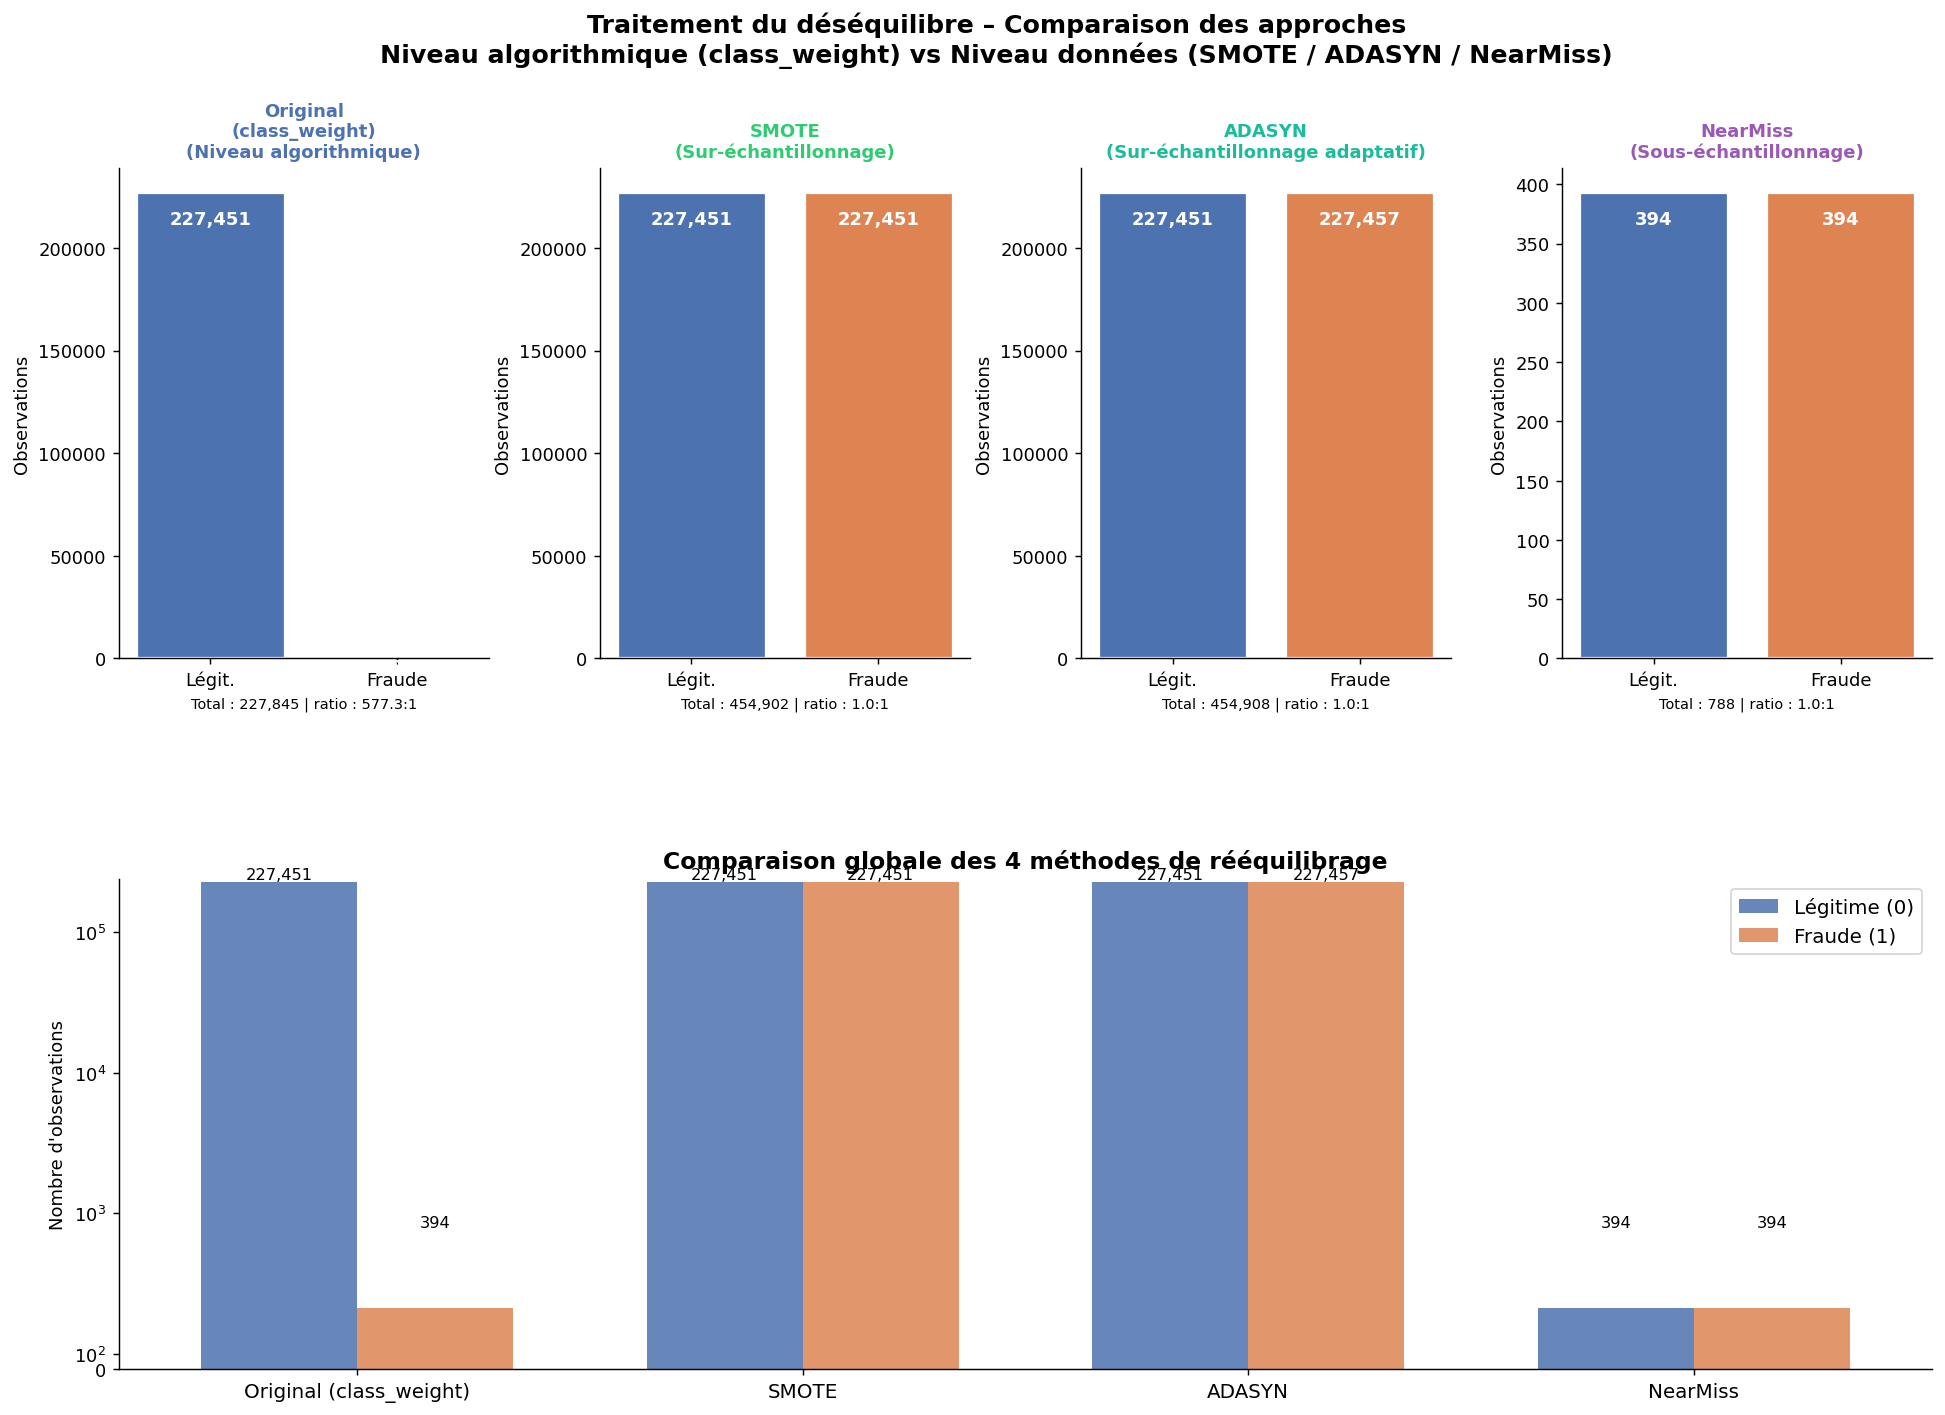

In [ ]:
methods_info = [
    ("Original\n(class_weight)", y_train,     C["maj"],    "Niveau algorithmique"),
    ("SMOTE",                    y_tr_smote,  C["green"],  "Sur-échantillonnage"),
    ("ADASYN",                   C["teal"],   C["teal"],   "Sur-échantillonnage"),
    ("NearMiss",                 y_tr_nm,     C["purple"], "Sous-échantillonnage"),
]

# Compter classe 0 et 1 pour chaque méthode
counts_list = [
    ("Original\n(class_weight)", pd.Series(y_train).value_counts(),       "Niveau algorithmique"),
    ("SMOTE",                    pd.Series(y_tr_smote).value_counts(),    "Sur-échantillonnage"),
    ("ADASYN",                   pd.Series(y_tr_adasyn).value_counts(),   "Sur-échantillonnage adaptatif"),
    ("NearMiss",                 pd.Series(y_tr_nm).value_counts(),       "Sous-échantillonnage"),
]

colors_methods = [C["maj"], C["green"], C["teal"], C["purple"]]

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.3)

# Ligne 1 : barchart par méthode
for col_i, (name, counts_m, desc) in enumerate(counts_list):
    ax = fig.add_subplot(gs[0, col_i])
    c0 = counts_m.get(0, 0)
    c1 = counts_m.get(1, 0)
    b = ax.bar(["Légit.", "Fraude"], [c0, c1],
               color=[C["maj"], C["min"]], edgecolor="white", linewidth=1.8)
    for bar, val in zip(b, [c0, c1]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 0.96,
                f"{val:,}", ha="center", va="top",
                color="white", fontweight="bold", fontsize=10)
    ax.set_title(f"{name}\n({desc})", fontsize=10, fontweight="bold",
                 color=colors_methods[col_i])
    ax.set_ylabel("Observations")
    total = c0 + c1
    ratio_local = c0 / max(c1, 1)
    ax.set_xlabel(f"Total : {total:,} | ratio : {ratio_local:.1f}:1", fontsize=8)

# Ligne 2 : comparaison synthétique (grouped bar)
ax_comp = fig.add_subplot(gs[1, :])
method_names = [c[0].replace("\n", " ") for c in counts_list]
x_pos = np.arange(len(method_names))
w = 0.35
legit_counts  = [c[1].get(0, 0) for c in counts_list]
fraud_counts  = [c[1].get(1, 0) for c in counts_list]

b1 = ax_comp.bar(x_pos - w/2, legit_counts, width=w,
                 color=C["maj"], alpha=0.85, label="Légitime (0)")
b2 = ax_comp.bar(x_pos + w/2, fraud_counts, width=w,
                 color=C["min"], alpha=0.85, label="Fraude (1)")

for bar, val in zip(list(b1) + list(b2), legit_counts + fraud_counts):
    ax_comp.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 500,
                 f"{val:,}", ha="center", va="bottom", fontsize=9)

ax_comp.set_xticks(x_pos)
ax_comp.set_xticklabels(method_names, fontsize=11)
ax_comp.set_ylabel("Nombre d'observations")
ax_comp.set_title("Comparaison globale des 4 méthodes de rééquilibrage",
                  fontsize=13, fontweight="bold")
ax_comp.legend(fontsize=11)
ax_comp.set_yscale("symlog", linthresh=1000)

plt.suptitle("Traitement du déséquilibre – Comparaison des approches\n"
             "Niveau algorithmique (class_weight) vs Niveau données (SMOTE / ADASYN / NearMiss)",
             fontsize=14, fontweight="bold")
save_fig(fig, "fig06_imbalance_methods_comparison.png")
plt.show()

### FIG 07 – Détail SMOTE : espace original vs augmenté


─── Figures détail par méthode ───
  ✓ fig07_smote_detail.png  →  C:\Users\DELL\Desktop\IA_P1\etape1_eda\figures\fig07_smote_detail.png


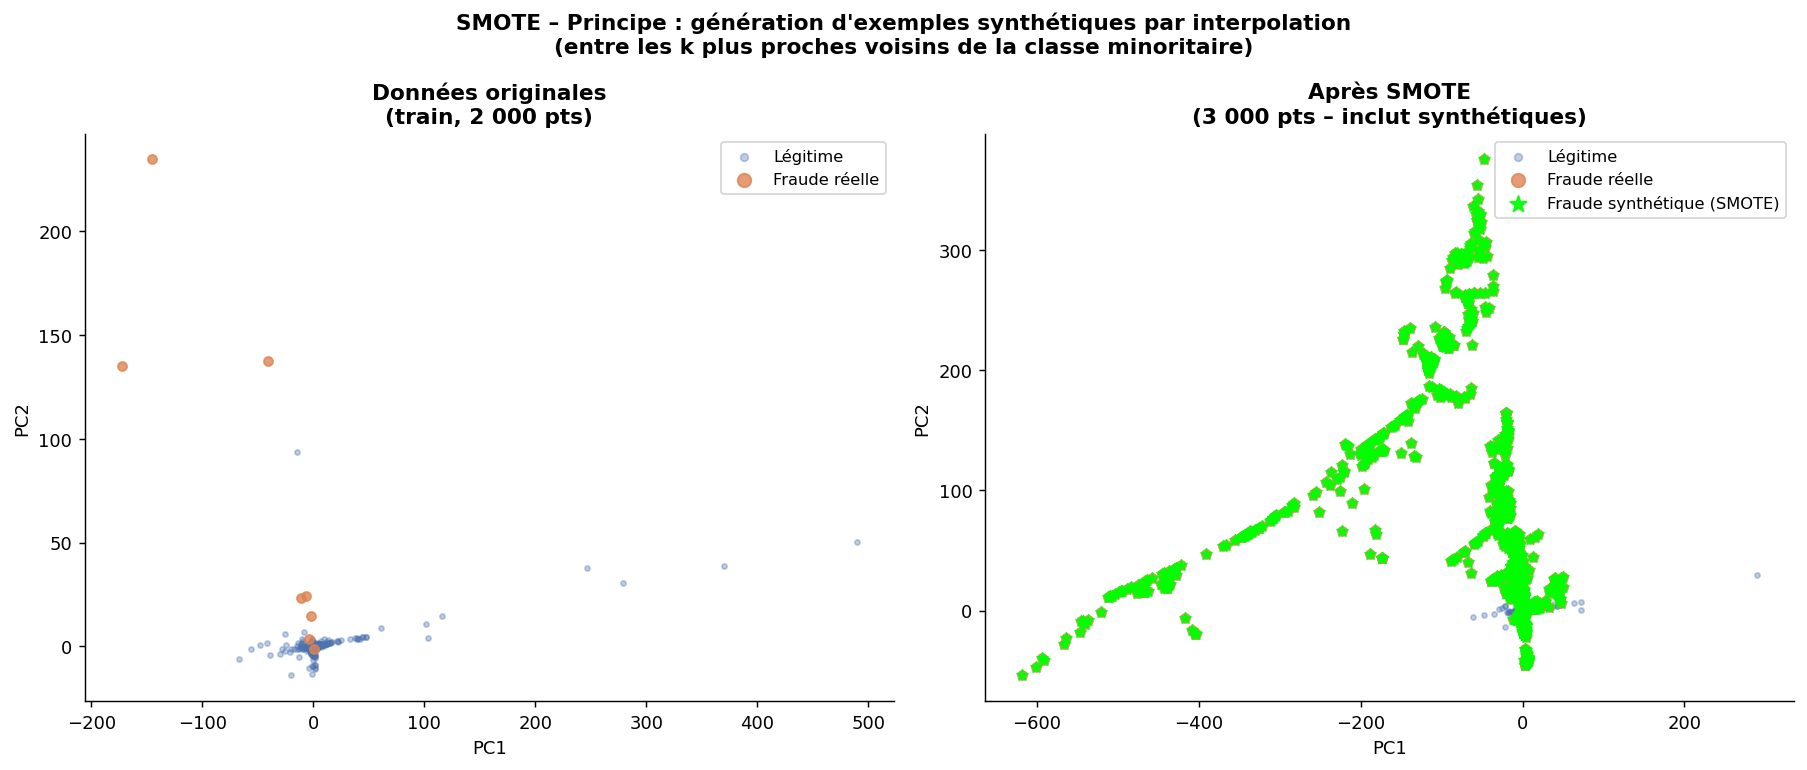

In [ ]:
print("\n─── Figures détail par méthode ───")

pca2 = PCA(n_components=2, random_state=RANDOM_STATE)

# PCA sur le train original pour référence
# On refait proprement
idx_sample = np.random.choice(len(X_train), 2000, replace=False)
X_orig_2k  = X_train.iloc[idx_sample].values
y_orig_2k  = y_train.iloc[idx_sample].values
pca2.fit(X_orig_2k)
X_orig_pca = pca2.transform(X_orig_2k)

# SMOTE – échantillon
idx_smote = np.random.choice(len(X_tr_smote), min(3000, len(X_tr_smote)), replace=False)
X_smote_pca = pca2.transform(X_tr_smote.values[idx_smote])
y_smote_samp = y_tr_smote.values[idx_smote]

# Identifier les points synthétiques (approximation : ceux au-delà de l'index original)
n_orig_train = len(X_train)
synthetic_mask = idx_smote >= n_orig_train

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (X_pca, y_s, title, show_synth, s_mask) in zip(axes, [
    (X_orig_pca, y_orig_2k, "Données originales\n(train, 2 000 pts)", False, None),
    (X_smote_pca, y_smote_samp, "Après SMOTE\n(3 000 pts – inclut synthétiques)", True, synthetic_mask),
]):
    ax.scatter(X_pca[y_s==0, 0], X_pca[y_s==0, 1], c=C["maj"], s=8,
               alpha=0.35, label="Légitime")
    ax.scatter(X_pca[y_s==1, 0], X_pca[y_s==1, 1], c=C["min"], s=25,
               alpha=0.8, label="Fraude réelle")
    if show_synth and s_mask is not None:
        synth_fraud = (y_s == 1) & s_mask
        ax.scatter(X_pca[synth_fraud, 0], X_pca[synth_fraud, 1],
                   c="lime", s=40, alpha=0.9, marker="*",
                   label="Fraude synthétique (SMOTE)", zorder=5)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.legend(fontsize=9, markerscale=1.5)

plt.suptitle("SMOTE – Principe : génération d'exemples synthétiques par interpolation\n"
             "(entre les k plus proches voisins de la classe minoritaire)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig07_smote_detail.png")
plt.show()

### FIG 08 – Détail ADASYN

  ✓ fig08_adasyn_detail.png  →  C:\Users\DELL\Desktop\IA_P1\etape1_eda\figures\fig08_adasyn_detail.png


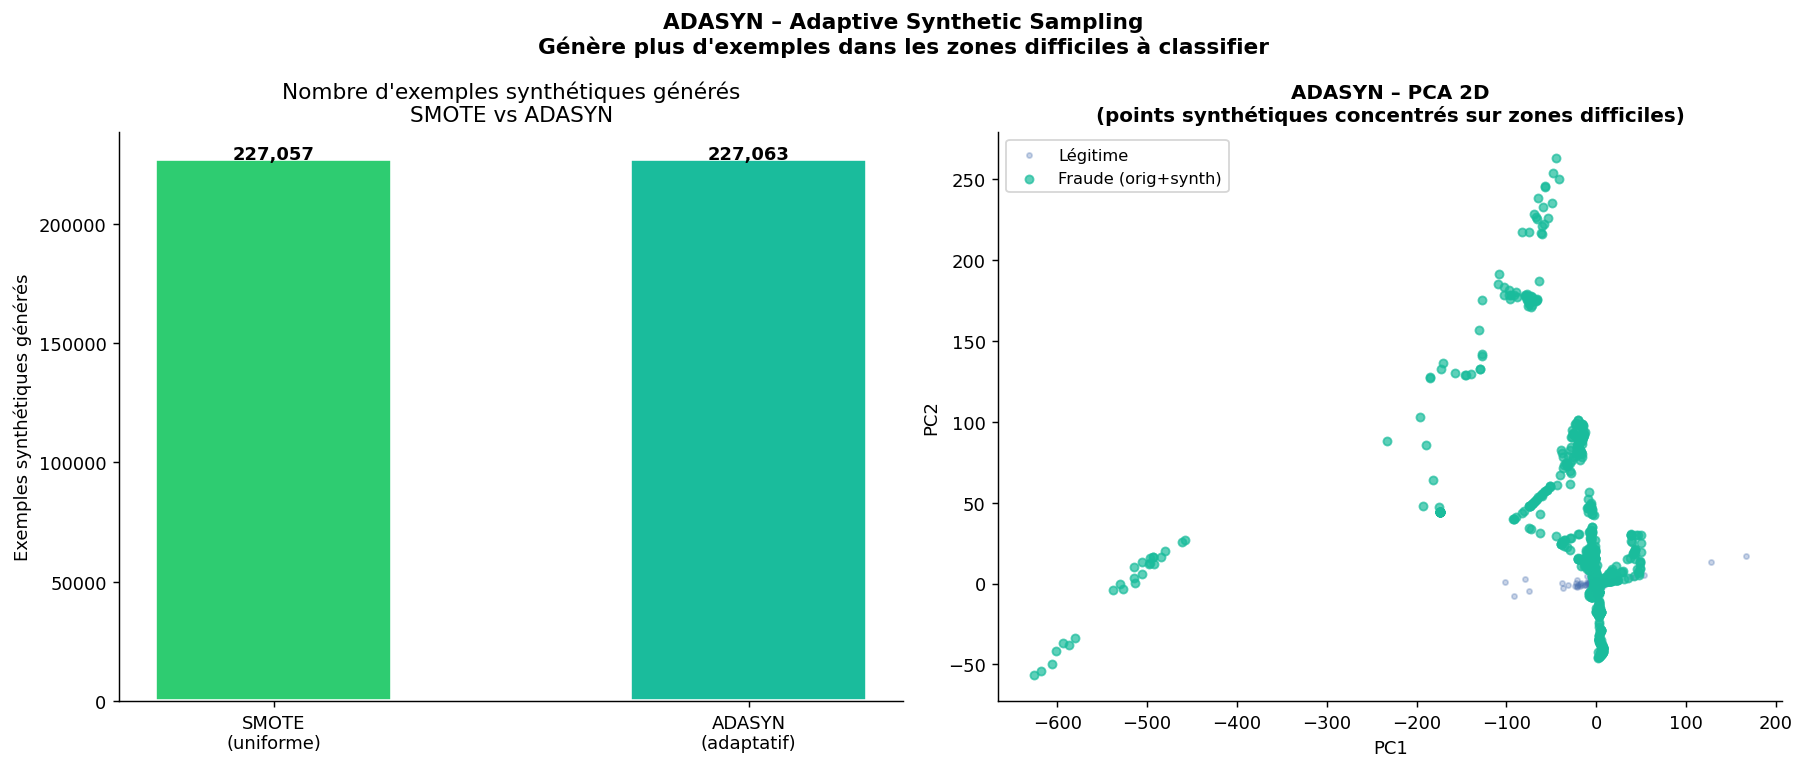

In [ ]:
idx_adasyn = np.random.choice(len(X_tr_adasyn), min(3000, len(X_tr_adasyn)), replace=False)
X_adasyn_pca = pca2.transform(X_tr_adasyn.values[idx_adasyn]
                               if hasattr(X_tr_adasyn, 'values') else X_tr_adasyn[idx_adasyn])
y_adasyn_samp = (y_tr_adasyn.values[idx_adasyn]
                  if hasattr(y_tr_adasyn, 'values') else y_tr_adasyn[idx_adasyn])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Distribution du nombre de synthétiques par région (histogram)
ax = axes[0]
n_synth_adasyn = len(X_tr_adasyn) - n_orig_train
n_synth_smote  = len(X_tr_smote)  - n_orig_train
ax.bar(["SMOTE\n(uniforme)", "ADASYN\n(adaptatif)"],
       [n_synth_smote, n_synth_adasyn],
       color=[C["green"], C["teal"]], edgecolor="white", linewidth=2, width=0.5)
ax.set_ylabel("Exemples synthétiques générés")
ax.set_title("Nombre d'exemples synthétiques générés\nSMOTE vs ADASYN")
for x, val in enumerate([n_synth_smote, n_synth_adasyn]):
    ax.text(x, val + 50, f"{val:,}", ha="center", fontweight="bold")

# PCA ADASYN
ax = axes[1]
ax.scatter(X_adasyn_pca[y_adasyn_samp==0, 0], X_adasyn_pca[y_adasyn_samp==0, 1],
           c=C["maj"], s=8, alpha=0.3, label="Légitime")
ax.scatter(X_adasyn_pca[y_adasyn_samp==1, 0], X_adasyn_pca[y_adasyn_samp==1, 1],
           c=C["teal"], s=20, alpha=0.7, label="Fraude (orig+synth)")
ax.set_title("ADASYN – PCA 2D\n(points synthétiques concentrés sur zones difficiles)",
             fontsize=11, fontweight="bold")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(fontsize=9)

plt.suptitle("ADASYN – Adaptive Synthetic Sampling\n"
             "Génère plus d'exemples dans les zones difficiles à classifier",
             fontsize=12, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig08_adasyn_detail.png")
plt.show()

### FIG 09 – Détail NearMiss

  ✓ fig09_nearmiss_detail.png  →  C:\Users\DELL\Desktop\IA_P1\etape1_eda\figures\fig09_nearmiss_detail.png


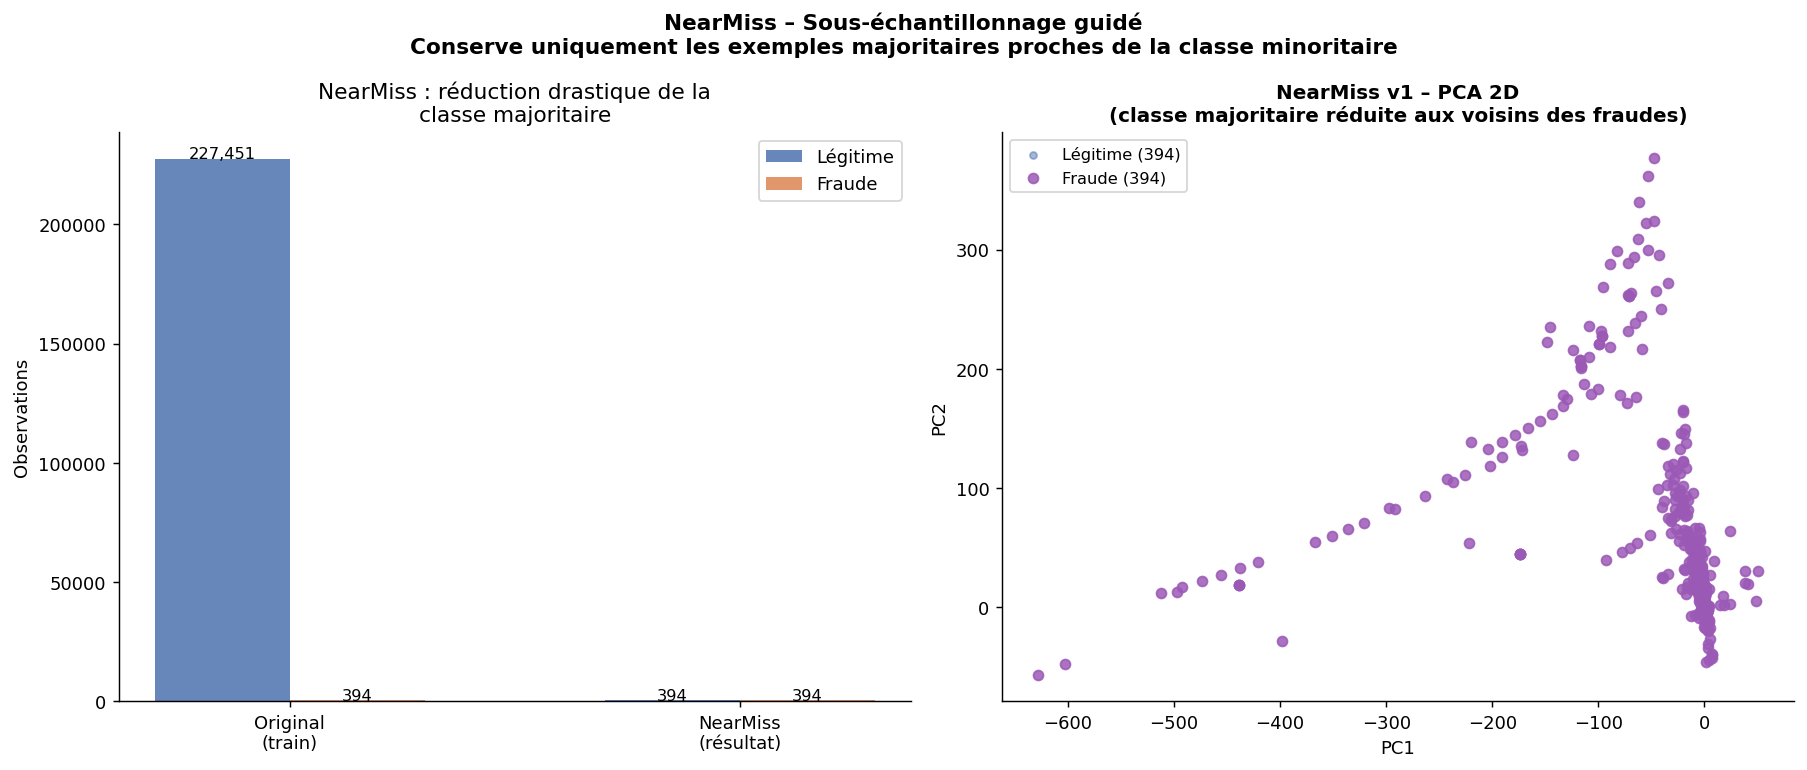

In [ ]:
idx_nm = np.random.choice(len(X_tr_nm), min(len(X_tr_nm), 2000), replace=False)
X_nm_2d  = pca2.transform(X_tr_nm.values[idx_nm]
                           if hasattr(X_tr_nm, 'values') else X_tr_nm[idx_nm])
y_nm_2d  = (y_tr_nm.values[idx_nm]
             if hasattr(y_tr_nm, 'values') else y_tr_nm[idx_nm])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Évolution du dataset
ax = axes[0]
stages = ["Original\n(train)", "NearMiss\n(résultat)"]
counts_stages = [
    [n_orig_train - y_train.sum(), y_train.sum()],
    [(y_tr_nm == 0).sum(), (y_tr_nm == 1).sum()],
]
x_pos_nm = np.arange(2)
w_nm = 0.3
for i, (lbl, col) in enumerate([("Légitime", C["maj"]), ("Fraude", C["min"])]):
    vals = [counts_stages[j][i] for j in range(2)]
    ax.bar(x_pos_nm + (i-0.5)*w_nm, vals, width=w_nm,
           color=col, alpha=0.85, label=lbl)
    for x, v in zip(x_pos_nm + (i-0.5)*w_nm, vals):
        ax.text(x, v + 200, f"{v:,}", ha="center", fontsize=9)
ax.set_xticks(x_pos_nm); ax.set_xticklabels(stages)
ax.set_ylabel("Observations")
ax.set_title("NearMiss : réduction drastique de la\nclasse majoritaire")
ax.legend()

# PCA NearMiss
ax = axes[1]
ax.scatter(X_nm_2d[y_nm_2d==0, 0], X_nm_2d[y_nm_2d==0, 1],
           c=C["maj"], s=15, alpha=0.5, label=f"Légitime ({(y_tr_nm==0).sum():,})")
ax.scatter(X_nm_2d[y_nm_2d==1, 0], X_nm_2d[y_nm_2d==1, 1],
           c=C["purple"], s=30, alpha=0.85, label=f"Fraude ({(y_tr_nm==1).sum():,})")
ax.set_title("NearMiss v1 – PCA 2D\n(classe majoritaire réduite aux voisins des fraudes)",
             fontsize=11, fontweight="bold")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(fontsize=9)

plt.suptitle("NearMiss – Sous-échantillonnage guidé\n"
             "Conserve uniquement les exemples majoritaires proches de la classe minoritaire",
             fontsize=12, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig09_nearmiss_detail.png")
plt.show()

### FIG 10 – Class Weight : visualisation de l'effet

  ✓ fig10_classweight_detail.png  →  C:\Users\DELL\Desktop\IA_P1\etape1_eda\figures\fig10_classweight_detail.png


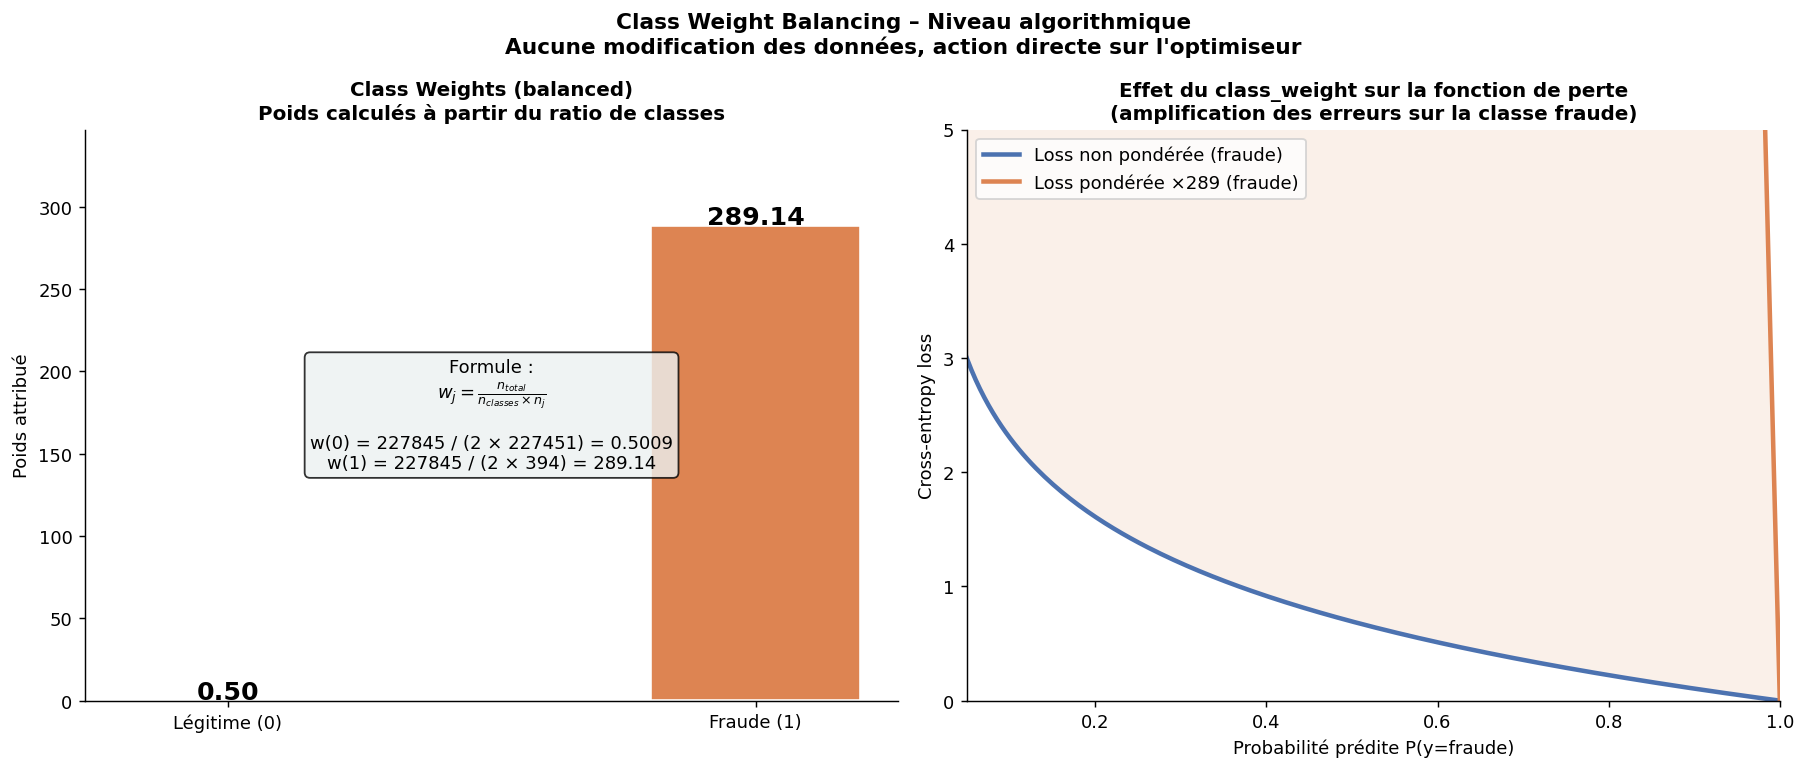

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Visualisation des poids
ax = axes[0]
classes_labels = ["Légitime (0)", "Fraude (1)"]
weights_vals   = [cw_dict[0], cw_dict[1]]
bars_w = ax.bar(classes_labels, weights_vals,
                color=[C["maj"], C["min"]], edgecolor="white", linewidth=2, width=0.4)
for bar, val in zip(bars_w, weights_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.2f}", ha="center", fontweight="bold", fontsize=14)
ax.set_ylabel("Poids attribué")
ax.set_title("Class Weights (balanced)\nPoids calculés à partir du ratio de classes",
             fontsize=11, fontweight="bold")
ax.set_ylim(0, max(weights_vals) * 1.2)

# Annotation de la formule
formula_text = (
    "Formule :\n"
    r"$w_j = \frac{n_{total}}{n_{classes} \times n_j}$"
    f"\n\nw(0) = {len(y_train)} / (2 × {(y_train==0).sum()}) = {cw_dict[0]:.4f}"
    f"\nw(1) = {len(y_train)} / (2 × {(y_train==1).sum()}) = {cw_dict[1]:.2f}"
)
ax.text(0.5, 0.5, formula_text, transform=ax.transAxes,
        fontsize=10, ha="center", va="center",
        bbox=dict(boxstyle="round", facecolor="#ecf0f1", alpha=0.8))

# Comparaison : impact sur la loss (schématique)
ax2 = axes[1]
x_range = np.linspace(0, 1, 200)
loss_unweighted = -np.log(x_range + 1e-9)
loss_weighted   = cw_dict[1] * (-np.log(x_range + 1e-9))

ax2.plot(x_range, loss_unweighted, color=C["maj"], lw=2.5, label="Loss non pondérée (fraude)")
ax2.plot(x_range, loss_weighted,   color=C["min"], lw=2.5, label=f"Loss pondérée ×{cw_dict[1]:.0f} (fraude)")
ax2.fill_between(x_range, loss_unweighted, loss_weighted,
                 alpha=0.12, color=C["min"])
ax2.set_xlim(0.05, 1); ax2.set_ylim(0, 5)
ax2.set_xlabel("Probabilité prédite P(y=fraude)")
ax2.set_ylabel("Cross-entropy loss")
ax2.set_title("Effet du class_weight sur la fonction de perte\n"
              "(amplification des erreurs sur la classe fraude)",
              fontsize=11, fontweight="bold")
ax2.legend(fontsize=10)

plt.suptitle("Class Weight Balancing – Niveau algorithmique\n"
             "Aucune modification des données, action directe sur l'optimiseur",
             fontsize=12, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig10_classweight_detail.png")
plt.show()

### FIG 11 – PCA 2D des 4 espaces rééchantillonnés (vue comparative)

  ✓ fig11_methods_pca_2d.png  →  C:\Users\DELL\Desktop\IA_P1\etape1_eda\figures\fig11_methods_pca_2d.png


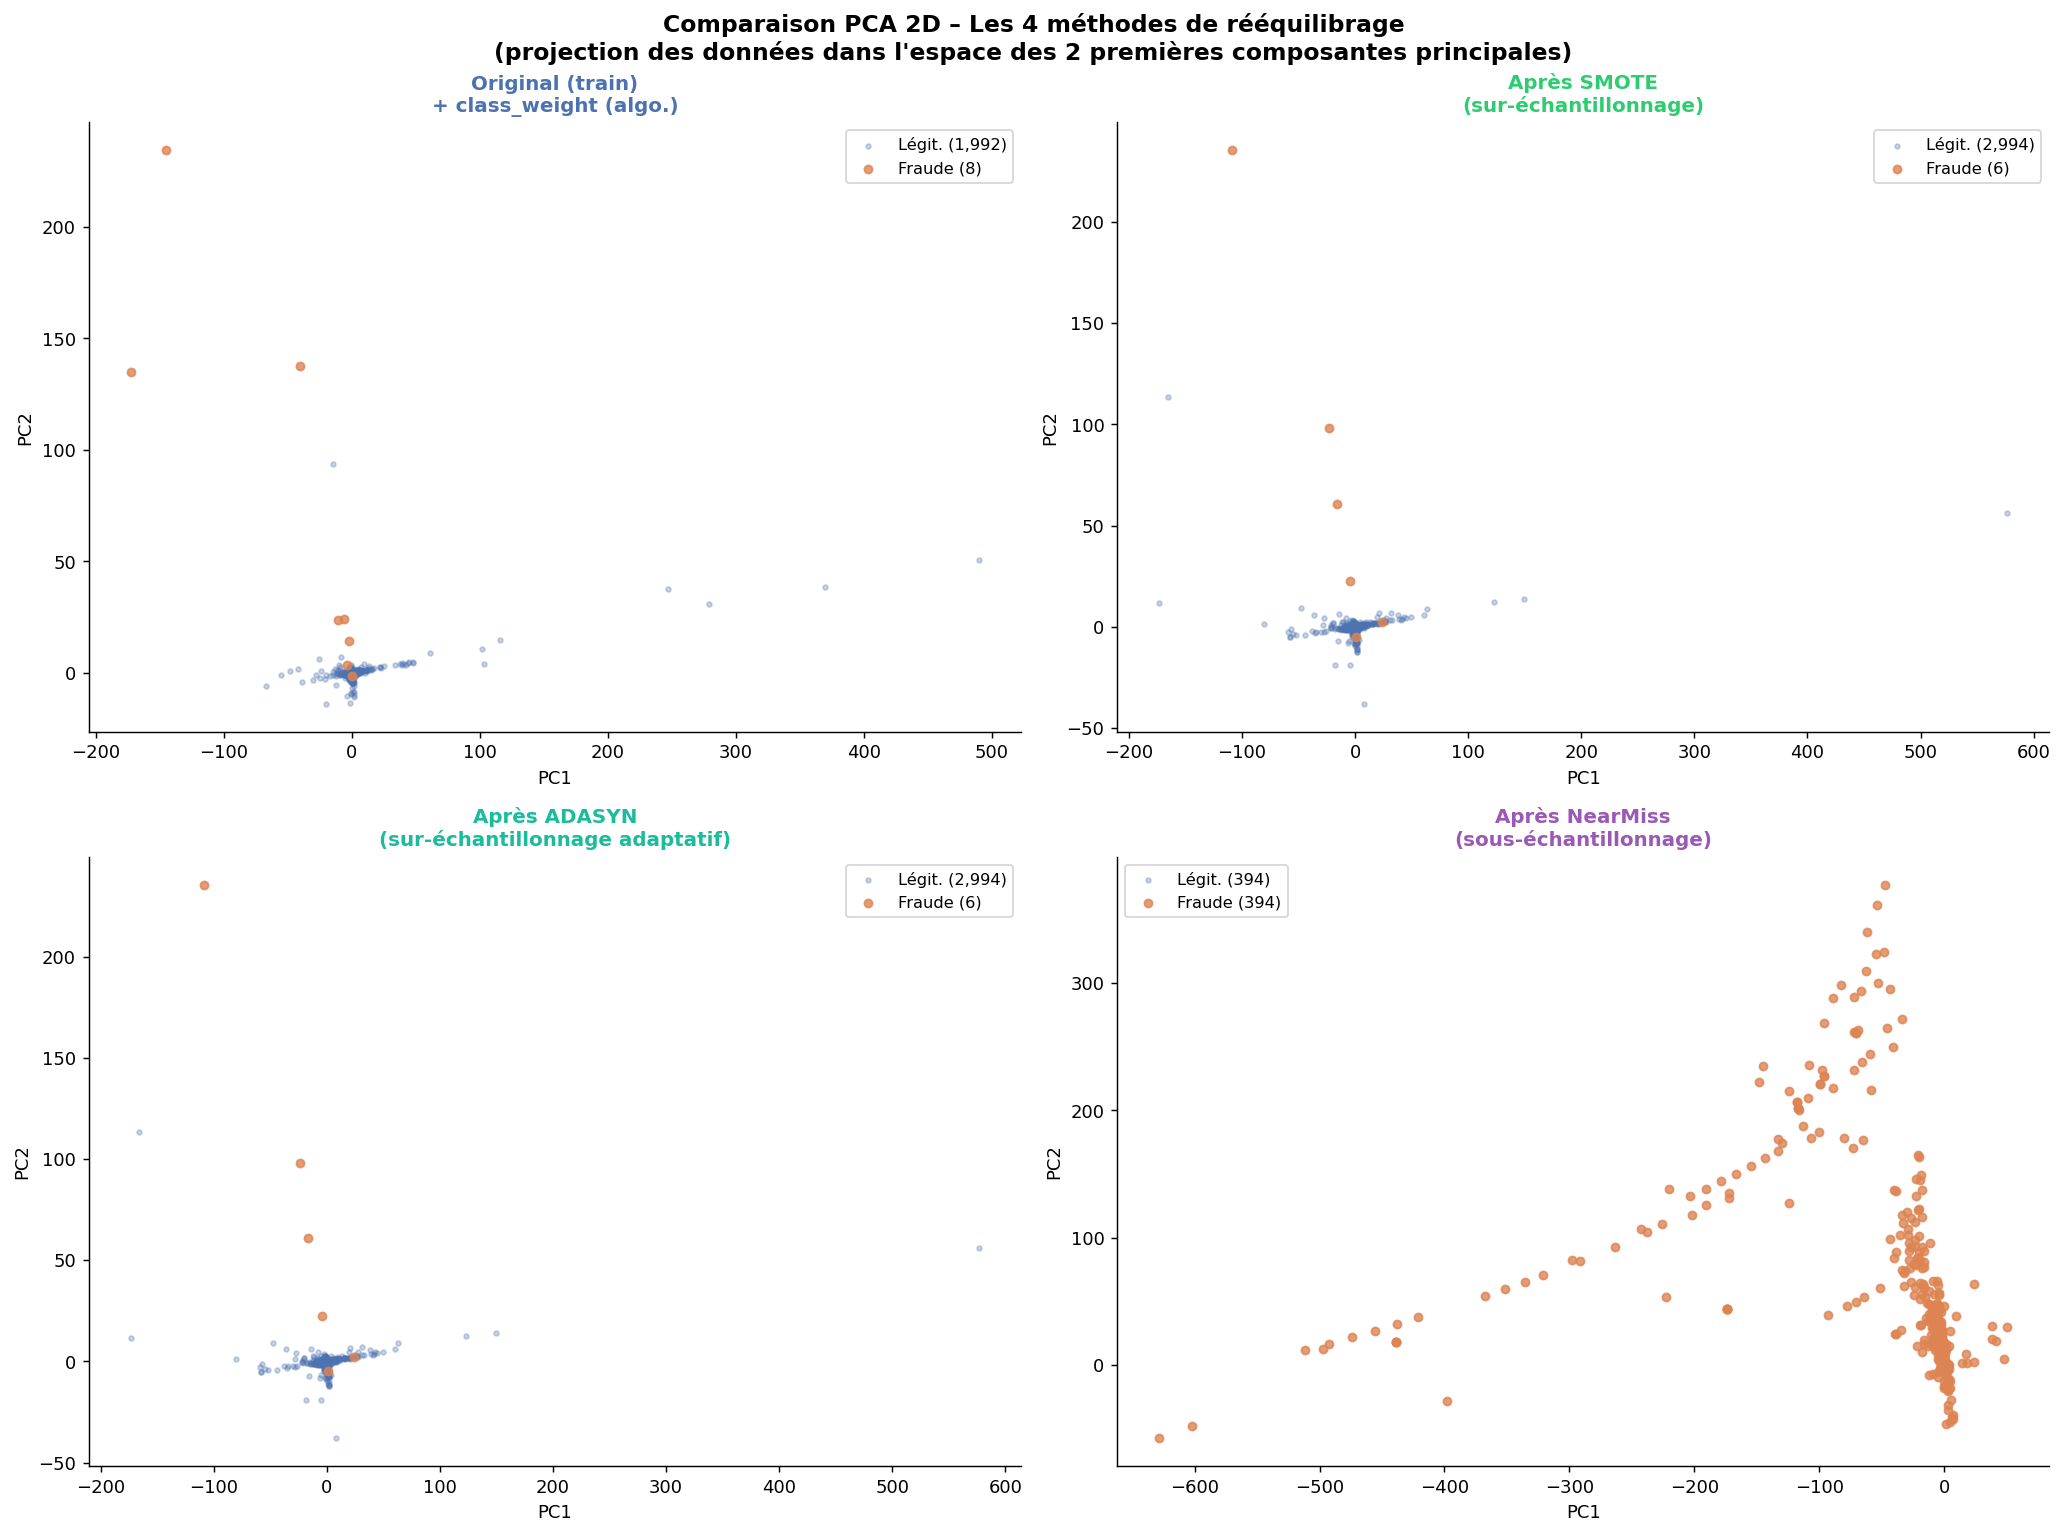

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

datasets = [
    ("Original (train)\n+ class_weight (algo.)", X_orig_2k, y_orig_2k,
     C["maj"], "•", "class_weight"),
    ("Après SMOTE\n(sur-échantillonnage)",
     X_tr_smote.values[:3000] if hasattr(X_tr_smote, 'values') else X_tr_smote[:3000],
     y_tr_smote.values[:3000] if hasattr(y_tr_smote, 'values') else y_tr_smote[:3000],
     C["green"], "•", "SMOTE"),
    ("Après ADASYN\n(sur-échantillonnage adaptatif)",
     X_tr_adasyn.values[:3000] if hasattr(X_tr_adasyn, 'values') else X_tr_adasyn[:3000],
     y_tr_adasyn.values[:3000] if hasattr(y_tr_adasyn, 'values') else y_tr_adasyn[:3000],
     C["teal"], "•", "ADASYN"),
    ("Après NearMiss\n(sous-échantillonnage)",
     X_tr_nm.values if hasattr(X_tr_nm, 'values') else X_tr_nm,
     y_tr_nm.values if hasattr(y_tr_nm, 'values') else y_tr_nm,
     C["purple"], "•", "NearMiss"),
]

for ax, (title, X_d, y_d, col, mk, method) in zip(axes, datasets):
    X_d_arr = X_d if isinstance(X_d, np.ndarray) else np.array(X_d)
    y_d_arr = y_d if isinstance(y_d, np.ndarray) else np.array(y_d)
    n_plot  = min(3000, len(X_d_arr))
    idx_p   = np.random.choice(len(X_d_arr), n_plot, replace=False)
    X_2d    = pca2.transform(X_d_arr[idx_p])
    y_2d    = y_d_arr[idx_p]

    ax.scatter(X_2d[y_2d==0, 0], X_2d[y_2d==0, 1],
               c=C["maj"], s=7, alpha=0.3, label=f"Légit. ({(y_d_arr==0).sum():,})")
    ax.scatter(X_2d[y_2d==1, 0], X_2d[y_2d==1, 1],
               c=C["min"], s=20, alpha=0.8, label=f"Fraude ({(y_d_arr==1).sum():,})")
    ax.set_title(title, fontsize=11, fontweight="bold", color=col)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.legend(fontsize=9)

plt.suptitle("Comparaison PCA 2D – Les 4 méthodes de rééquilibrage\n"
             "(projection des données dans l'espace des 2 premières composantes principales)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig11_methods_pca_2d.png")
plt.show()

### FIG 12 – Distributions V1-V28

  ✓ fig12_pca_features_distribution.png  →  C:\Users\DELL\Desktop\IA_P1\etape1_eda\figures\fig12_pca_features_distribution.png


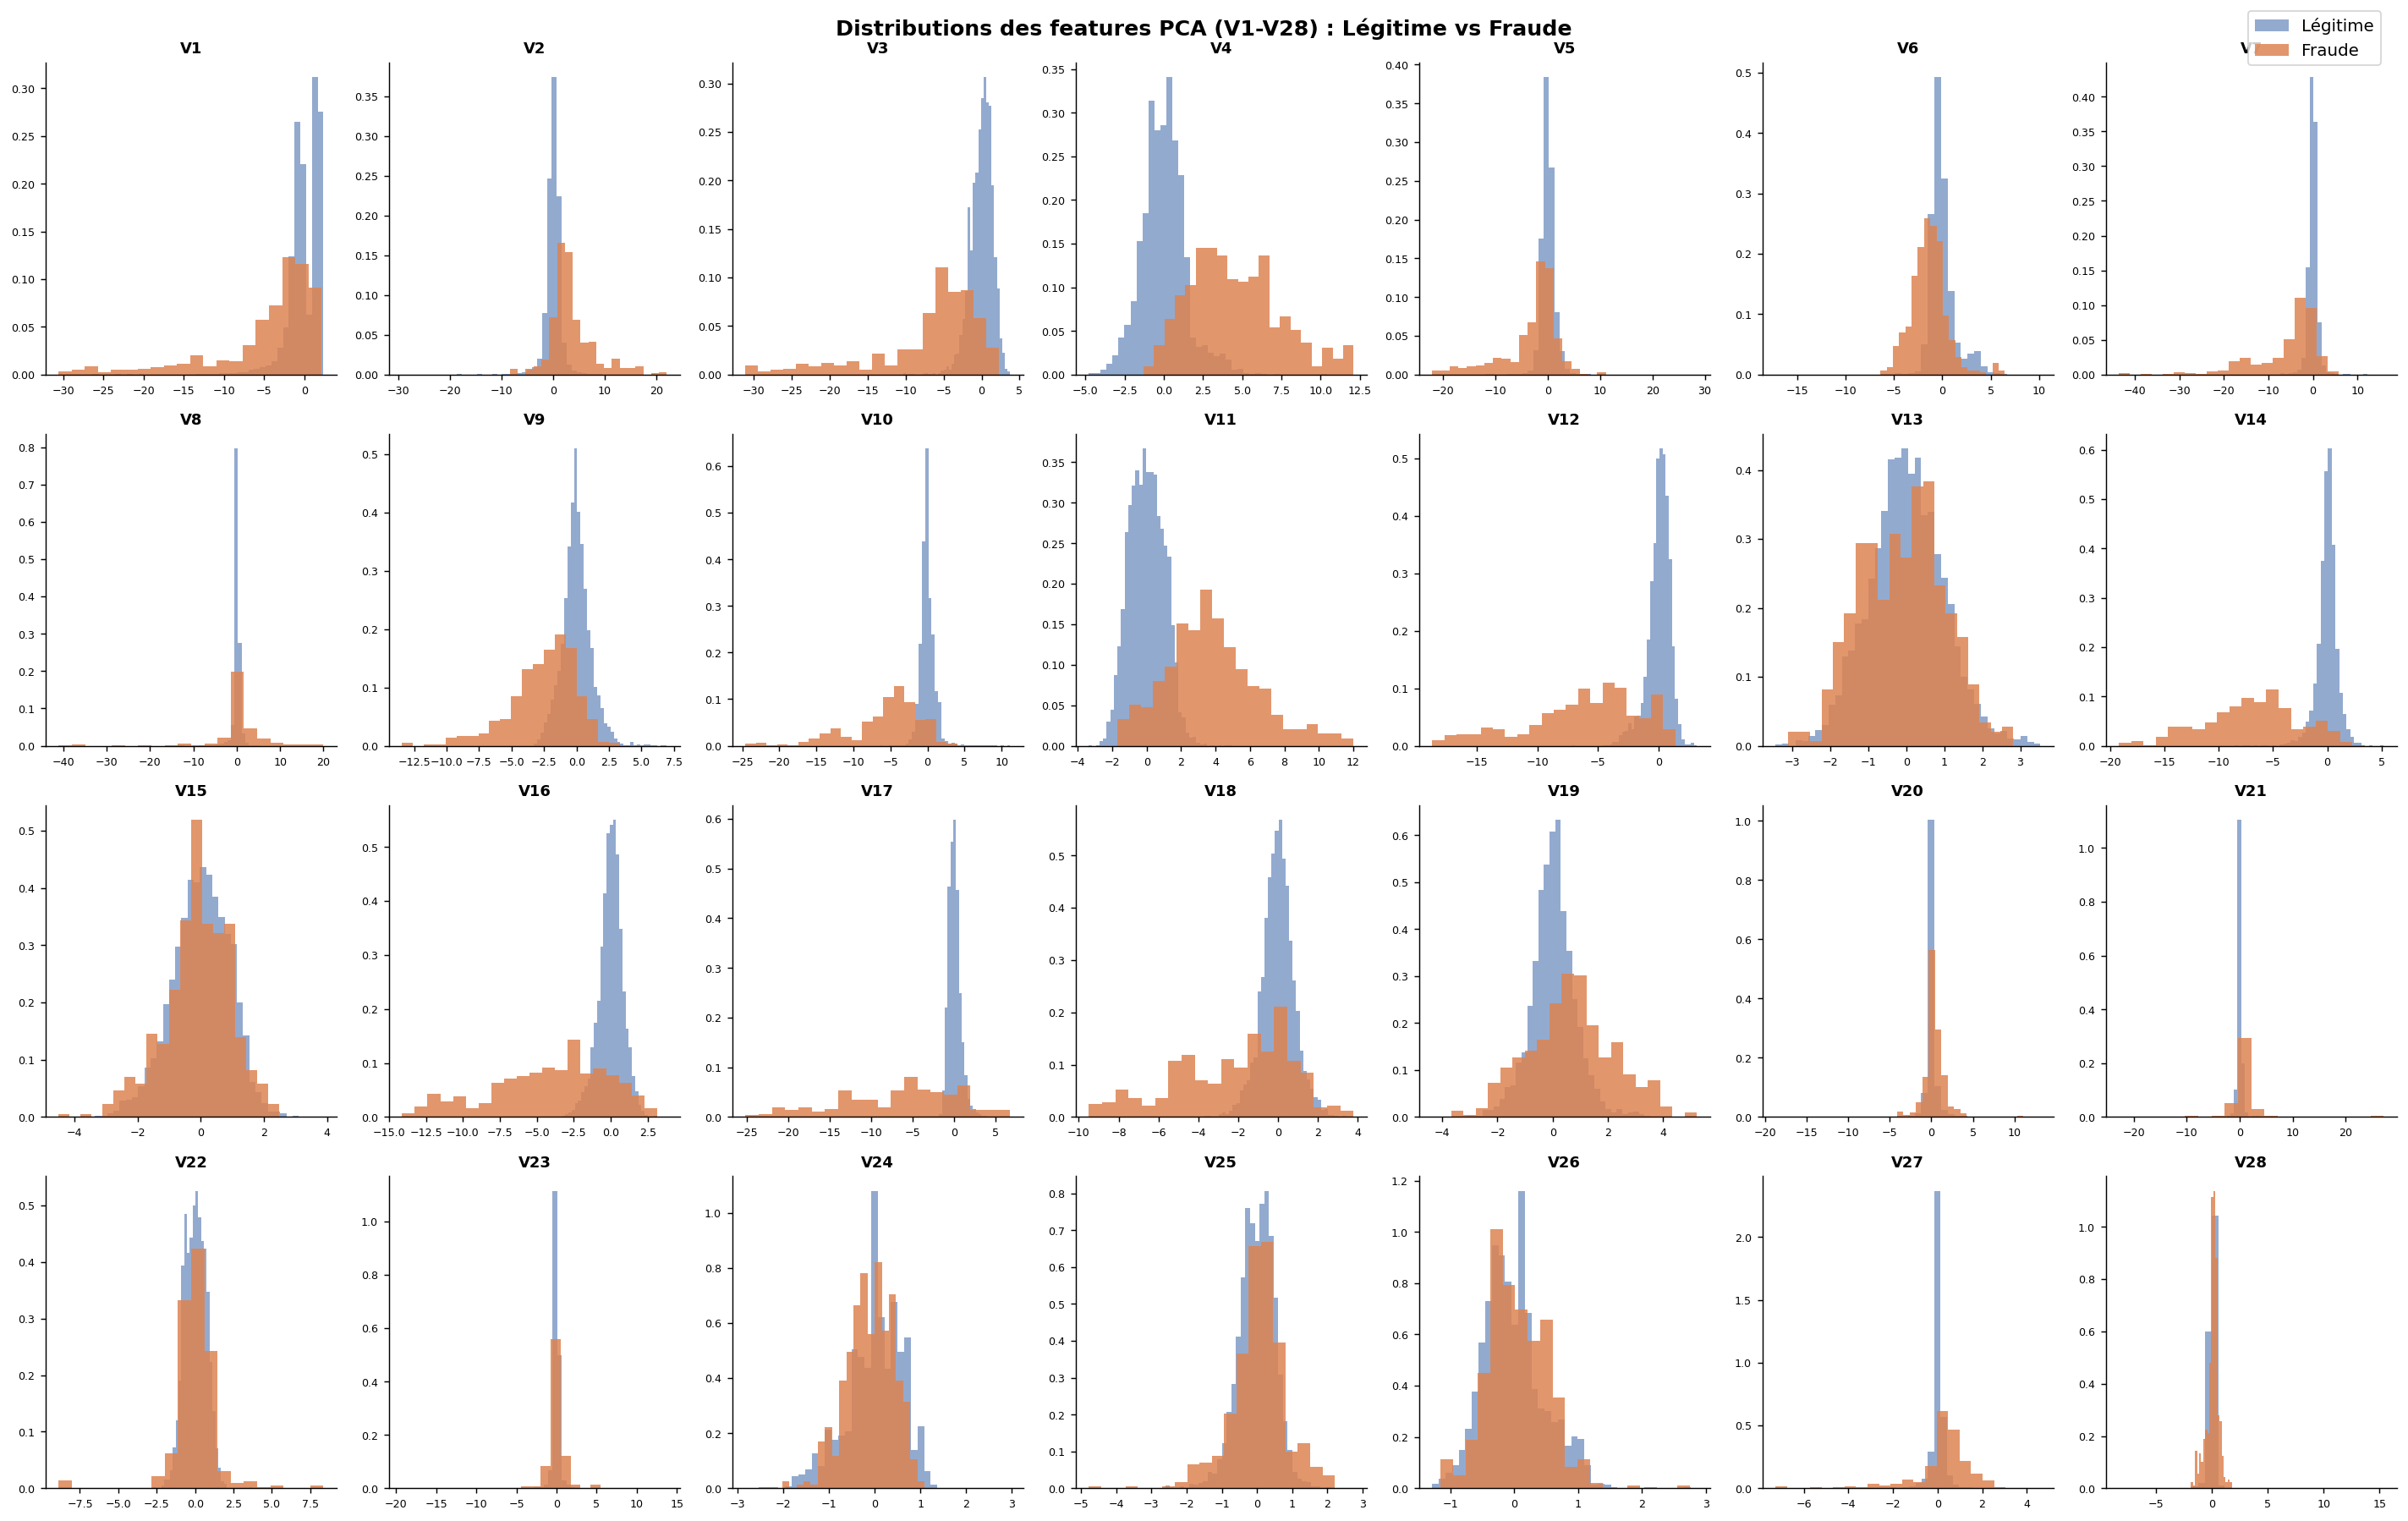

In [ ]:
v_features   = [f"V{i}" for i in range(1, 29)]
sample_legit = df[df["Class"] == 0][v_features].sample(5000, random_state=RANDOM_STATE)
sample_fraud = df[df["Class"] == 1][v_features]

fig, axes = plt.subplots(4, 7, figsize=(22, 14))
axes = axes.flatten()

for i, feat in enumerate(v_features):
    ax = axes[i]
    ax.hist(sample_legit[feat], bins=40, color=C["maj"], alpha=0.6, density=True)
    ax.hist(sample_fraud[feat], bins=20, color=C["min"], alpha=0.85, density=True)
    ax.set_title(feat, fontsize=10, fontweight="bold")
    ax.tick_params(labelsize=7)

handles = [
    Patch(facecolor=C["maj"], alpha=0.6, label="Légitime"),
    Patch(facecolor=C["min"], alpha=0.85, label="Fraude"),
]
fig.legend(handles=handles, loc="upper right", fontsize=11, bbox_to_anchor=(0.99, 0.99))
plt.suptitle("Distributions des features PCA (V1-V28) : Légitime vs Fraude",
             fontsize=14, fontweight="bold")
plt.tight_layout()
save_fig(fig, "fig12_pca_features_distribution.png")
plt.show()

### SAUVEGARDE pickle

In [ ]:
prepared = {
    "X_train":        X_train,
    "X_test":         X_test,
    "y_train":        y_train,
    "y_test":         y_test,
    "X_train_smote":  X_tr_smote,
    "y_train_smote":  y_tr_smote,
    "X_train_adasyn": X_tr_adasyn,
    "y_train_adasyn": y_tr_adasyn,
    "X_train_nm":     X_tr_nm,
    "y_train_nm":     y_tr_nm,
    "class_weight":   cw_dict,
    "scaler":         scaler,
    "scale_cols":     scale_cols,
    "mi_scores":      mi_series,
    "selected_features": selected_features,
    "vif_data":       vif_data,
}
with open(OUT_PICKLE, "wb") as f:
    pickle.dump(prepared, f)

print(f"\n✓ Données sauvegardées → {OUT_PICKLE}")
print("\n" + "─" * 65)
print(f"ÉTAPE 1 TERMINÉE – 12 figures générées dans :")
print(f"  {FIG_DIR}")
print("─" * 65)


✓ Données sauvegardées → C:\Users\DELL\Desktop\IA_P1\etape1_eda\prepared_data.pkl

─────────────────────────────────────────────────────────────────
ÉTAPE 1 TERMINÉE – 12 figures générées dans :
  C:\Users\DELL\Desktop\IA_P1\etape1_eda\figures
─────────────────────────────────────────────────────────────────
